# Testing Different Fitbit Cleaning Iterations

In [ ]:
# https://pmc.ncbi.nlm.nih.gov/articles/PMC7191872/
# paper talking about using clinical grade actiwatches. Says you can compute STD of minutes asleep,
# they recommend at least 7 days

In [1]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np

warnings.simplefilter("ignore")

# pull down sleep data and drop rows missing sleep start time, public client id, or days in program
fitbit = get_snapshot("wearables")
own_device_clients = fitbit[fitbit.days_in_program < 0].public_client_id.unique()
fitbit = fitbit[fitbit.days_in_program >= 0]
fitbit['own_device'] = fitbit.public_client_id.isin(own_device_clients)
fitbit = fitbit.dropna(subset=['sleep_startTime', 'public_client_id', 'days_in_program'])

# identify sleep and activity columns
sleep_features = fitbit.filter(like='sleep').columns[:-1].tolist()
activity_features = fitbit.filter(like='activities').columns.tolist()
hr_features = fitbit.filter(like='heartrate').columns.tolist()
sleep_and_activity_features = sleep_features + activity_features

# extract dates from sleep_startTime and rename days in program
fitbit['sleep_date'] = pd.to_datetime(fitbit.sleep_startTime, format='mixed').dt.date
fitbit['sleep_startTime'] = pd.to_datetime(fitbit.sleep_startTime, format='mixed')
fitbit = fitbit.sort_values(by='days_in_program')
fitbit['fitbit_dip'] = fitbit['days_in_program']
fitbit.drop(columns='days_in_program', axis=1, inplace=True)

# make a new column that converts sleep_startTime to a 48 hour period bedtime integer
def time_to_hours(dt):
    """
    Convert 24 hour clock time to numerical hours within a 48-hour window.
    Times between midnight and noon (ie 00:00-12:00) are treated as within the second day 
    (e.g., 01:00am → 24 + 1 = 25.0).
    """
    if dt.hour < 12:  # Times before noon are considered part of the second day in a 48 hour period
        return 24 + dt.hour + dt.minute / 60 + dt.second / 3600
    else:
        return dt.hour + dt.minute / 60 + dt.second / 3600

fitbit['bedtime_int'] = fitbit.sleep_startTime.apply(time_to_hours)

In [4]:
fitbit.bedtime_int.describe()

count    958329.000000
mean         22.954338
std           2.186395
min          12.000000
25%          21.858333
50%          22.800000
75%          23.875000
max          35.991667
Name: bedtime_int, dtype: float64

In [2]:
fitbit.month.value_counts(normalize=True)

month
Mar    0.096624
Apr    0.096137
Jan    0.088832
Feb    0.083788
Dec    0.082967
Oct    0.082849
Aug    0.081886
May    0.081310
Sep    0.080770
Nov    0.080507
Jul    0.075273
Jun    0.069057
Name: proportion, dtype: float64

In [2]:
fitbit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 958329 entries, 1269149 to 1805376
Data columns (total 35 columns):
 #   Column                           Non-Null Count   Dtype              
---  ------                           --------------   -----              
 0   public_client_id                 958329 non-null  object             
 1   vendor                           958329 non-null  object             
 2   days_since_first_call            947970 non-null  float64            
 3   days_since_first_draw            944685 non-null  float64            
 4   month                            958329 non-null  object             
 5   weekday                          958329 non-null  object             
 6   season                           958329 non-null  object             
 7   activities_activityCalories      932894 non-null  float64            
 8   activities_calories              932894 non-null  float64            
 9   activities_distance              946980 non-null  float64

### Define missingness groups and reassign the missingness groups to vendor column

In [3]:
# No need to include sleep_startTime since we already dropped all the rows w nan in that column
fitbit.columns[7:30]

Index(['activities_activityCalories', 'activities_calories',
       'activities_distance', 'activities_elevation', 'activities_floors',
       'activities_minutesFairlyActive', 'activities_minutesLightlyActive',
       'activities_minutesSedentary', 'activities_minutesVeryActive',
       'activities_steps', 'heartrate_cardio', 'heartrate_fatburn',
       'heartrate_peak', 'heartrate_resting', 'sleep_awakeDuration',
       'sleep_awakeningsCount', 'sleep_efficiency', 'sleep_minutesAfterWakeup',
       'sleep_minutesAsleep', 'sleep_minutesAwake',
       'sleep_minutesToFallAsleep', 'sleep_restlessDuration',
       'sleep_timeInBed'],
      dtype='object')

In [2]:
import pandas as pd

# Step 1: Convert missing values to a binary format (1 = missing, 0 = present)
missingness_patterns = fitbit[fitbit.columns[7:30]].isnull().astype(int)

# Step 2: Identify unique missingness patterns and assign a group ID
missingness_patterns["missingness_group"] = missingness_patterns.apply(lambda row: tuple(row), axis=1)
missingness_patterns["missingness_group"] = missingness_patterns["missingness_group"].astype("category").cat.codes

# Step 3: Merge group IDs back to original DataFrame
fitbit["missingness_group"] = missingness_patterns["missingness_group"]

# Step 4: Count the number of rows in each missingness group
missingness_group_counts = fitbit["missingness_group"].value_counts().reset_index()
missingness_group_counts.columns = ["missingness_group", "count"]
missingness_group_counts["percentage"] = round((missingness_group_counts["count"] / len(fitbit)) * 100, 2)

# Step 5: Extract and display unique missingness patterns
unique_missingness_patterns = missingness_patterns.drop(columns="missingness_group").drop_duplicates()
unique_missingness_patterns["missingness_group"] = fitbit["missingness_group"].unique()

In [3]:
# find proportion that each missingness group makes up
group_sizes = fitbit.missingness_group.value_counts(normalize=True)

# drop missingness groups making up less than 1% of the data
valid_groups = group_sizes[group_sizes > 0.01].index

# Step 3: Filter the DataFrame to keep only rows belonging to valid groups
fitbit = fitbit[fitbit.missingness_group.isin(valid_groups)]

In [6]:
group_sizes

missingness_group
2     0.454534
1     0.248384
0     0.153153
4     0.082470
5     0.026993
11    0.009162
6     0.004584
12    0.004420
16    0.003317
21    0.002097
20    0.002012
15    0.001893
3     0.001719
10    0.001221
13    0.001117
19    0.001084
14    0.000847
17    0.000591
8     0.000398
9     0.000003
7     0.000001
18    0.000001
Name: proportion, dtype: float64

In [4]:
fitbit['vendor'] = fitbit.missingness_group
fitbit.drop(columns='missingness_group', inplace=True)

In [5]:
fitbit['vendor'] = fitbit.vendor.replace({
    0: 'miss0',
    1: 'miss1',
    2: 'miss2',
    4: 'miss4',
    5: 'miss5'
})

In [6]:
# check that we are only keeping the 5 missingness groups
fitbit.vendor.value_counts()

vendor
miss2    435593
miss1    238034
miss0    146771
miss4     79033
miss5     25868
Name: count, dtype: int64

In [10]:
fitbit.vendor.info()

<class 'pandas.core.series.Series'>
Index: 925299 entries, 1269149 to 1805376
Series name: vendor
Non-Null Count   Dtype 
--------------   ----- 
925299 non-null  object
dtypes: object(1)
memory usage: 14.1+ MB


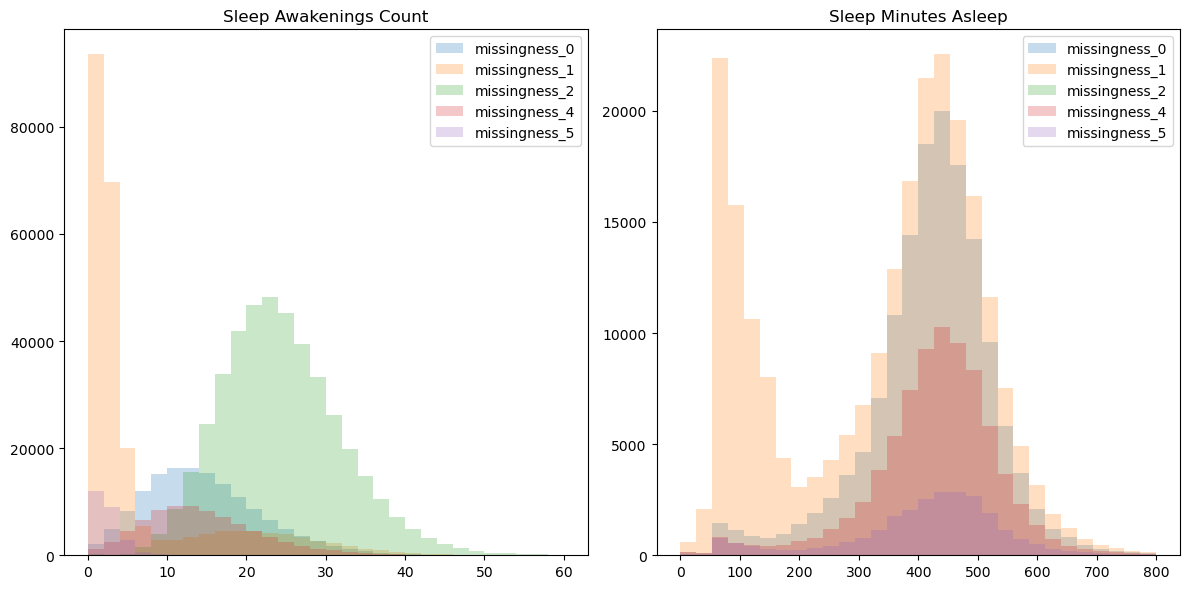

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].set_title('Sleep Awakenings Count')
axs[0].hist(fitbit[fitbit.missingness_group == 0]['sleep_awakeningsCount'], bins=30, label="missingness_0", alpha=0.25, range=[0,60])
axs[0].hist(fitbit[fitbit.missingness_group == 1]['sleep_awakeningsCount'], bins=30, label="missingness_1", alpha=0.25, range=[0,60])
axs[0].hist(fitbit[fitbit.missingness_group == 2]['sleep_awakeningsCount'], bins=30, label="missingness_2", alpha=0.25, range=[0,60])
axs[0].hist(fitbit[fitbit.missingness_group == 4]['sleep_awakeningsCount'], bins=30, label="missingness_4", alpha=0.25, range=[0,60])
axs[0].hist(fitbit[fitbit.missingness_group == 5]['sleep_awakeningsCount'], bins=30, label="missingness_5", alpha=0.25, range=[0,60])
axs[0].legend()

axs[1].set_title('Sleep Minutes Asleep')
axs[1].hist(fitbit[fitbit.missingness_group == 0]['sleep_minutesAsleep'], bins=30, label="missingness_0", alpha=0.25, range=[0,800])
axs[1].hist(fitbit[fitbit.missingness_group == 1]['sleep_minutesAsleep'], bins=30, label="missingness_1", alpha=0.25, range=[0,800])
axs[1].hist(fitbit[fitbit.missingness_group == 2]['sleep_minutesAsleep'], bins=30, label="missingness_2", alpha=0.25, range=[0,800])
axs[1].hist(fitbit[fitbit.missingness_group == 4]['sleep_minutesAsleep'], bins=30, label="missingness_4", alpha=0.25, range=[0,800])
axs[1].hist(fitbit[fitbit.missingness_group == 5]['sleep_minutesAsleep'], bins=30, label="missingness_5", alpha=0.25, range=[0,800])
axs[1].legend()

plt.tight_layout()
plt.show()

### Checking missingness patterns

In [37]:
import pandas as pd

# Step 1: Convert missing values to a binary format (1 = missing, 0 = present)
missingness_patterns = fitbit[fitbit.columns[8:32]].isnull().astype(int)

# Step 2: Identify unique missingness patterns and assign a group ID
missingness_patterns["missingness_group"] = missingness_patterns.apply(lambda row: tuple(row), axis=1)
missingness_patterns["missingness_group"] = missingness_patterns["missingness_group"].astype("category").cat.codes

# Step 3: Merge group IDs back to original DataFrame
fitbit["missingness_group"] = missingness_patterns["missingness_group"]

# Step 4: Count the number of rows in each missingness group
missingness_group_counts = fitbit["missingness_group"].value_counts().reset_index()
missingness_group_counts.columns = ["missingness_group", "count"]
missingness_group_counts["percentage"] = round((missingness_group_counts["count"] / len(fitbit)) * 100, 2)

# Step 5: Extract and display unique missingness patterns
unique_missingness_patterns = missingness_patterns.drop(columns="missingness_group").drop_duplicates()
unique_missingness_patterns["missingness_group"] = fitbit["missingness_group"].unique()

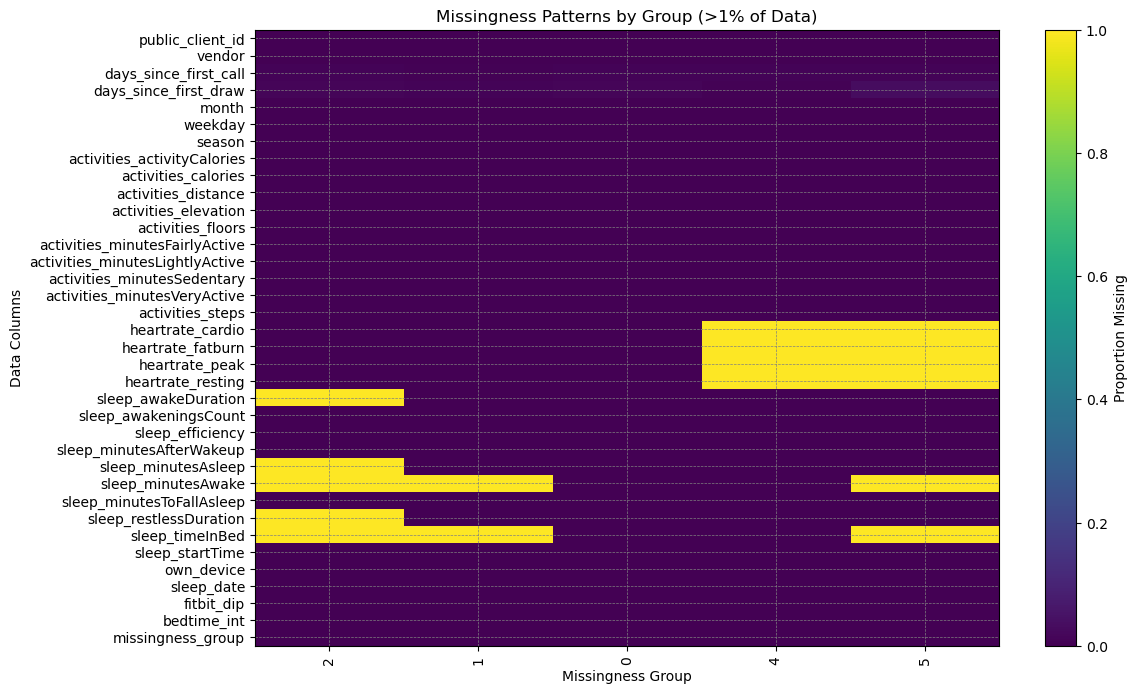

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Compute missingness percentage per group
missingness_by_group = fitbit.groupby("missingness_group").apply(lambda x: x.isnull().mean())

# Step 2: Compute group sizes and filter groups with >1% of total data
group_sizes = fitbit["missingness_group"].value_counts(normalize=True) * 100
valid_groups = group_sizes[group_sizes > 1].index  # Select groups with more than 1% of data

# Step 3: Filter missingness_by_group to include only valid groups
filtered_missingness_by_group = missingness_by_group.loc[valid_groups]

# Step 4: Plot heatmap of filtered missingness patterns by group
plt.figure(figsize=(12, 8))

# Use 'viridis' for a better contrast heatmap
plt.imshow(filtered_missingness_by_group.T, aspect="auto", cmap="viridis", interpolation="none")

# Add grid lines
plt.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.5)

# Add colorbar
plt.colorbar(label="Proportion Missing")

# Customize axis ticks
plt.xticks(ticks=np.arange(len(filtered_missingness_by_group.index)), labels=filtered_missingness_by_group.index, rotation=90)
plt.yticks(ticks=np.arange(len(filtered_missingness_by_group.columns)), labels=filtered_missingness_by_group.columns)

# Improve title and labels
plt.title("Missingness Patterns by Group (>1% of Data)")
plt.xlabel("Missingness Group")
plt.ylabel("Data Columns")

# Show plot
plt.show()


In [5]:
fitbit.missingness_group.value_counts()

missingness_group
2     435593
1     238034
0     146771
4      79033
5      25868
11      8780
6       4393
12      4236
16      3179
21      2010
20      1928
15      1814
3       1647
10      1170
13      1070
19      1039
14       812
17       566
8        381
9          3
7          1
18         1
Name: count, dtype: int64

In [14]:
fitbit.groupby('missingness_group')['vendor'].value_counts(normalize=True).unstack()

vendor,FitBit,hapi-fitbit
missingness_group,,
0,1.0,NaN
1,NaN,1.0
2,NaN,1.0
4,1.0,NaN
5,NaN,1.0


In [38]:
# find proportion that each missingness group makes up
group_sizes = fitbit.missingness_group.value_counts(normalize=True)

# drop missingness groups making up less than 1% of the data
valid_groups = group_sizes[group_sizes > 0.01].index

# Step 3: Filter the DataFrame to keep only rows belonging to valid groups
fitbit = fitbit[fitbit.missingness_group.isin(valid_groups)]

In [39]:
group_sizes

missingness_group
2     0.454534
1     0.248384
0     0.153153
4     0.082470
5     0.026993
11    0.009162
6     0.004584
12    0.004420
16    0.003317
21    0.002097
20    0.002012
15    0.001893
3     0.001719
10    0.001221
13    0.001117
19    0.001084
14    0.000847
17    0.000591
8     0.000398
9     0.000003
7     0.000001
18    0.000001
Name: proportion, dtype: float64

In [7]:
fitbit.shape

(925299, 36)

In [8]:
fitbit.shape

(925299, 36)

In [9]:
fitbit.missingness_group.value_counts()[:5].sum()

925299

In [40]:
fitbit['vendor'] = fitbit.missingness_group
fitbit.drop(columns='missingness_group', inplace=True)

In [41]:
fitbit['vendor'] = fitbit.vendor.replace({
    0: 'miss0',
    1: 'miss1',
    2: 'miss2',
    4: 'miss4',
    5: 'miss5'
})

In [42]:
fitbit.vendor.value_counts()

vendor
miss2    435593
miss1    238034
miss0    146771
miss4     79033
miss5     25868
Name: count, dtype: int64

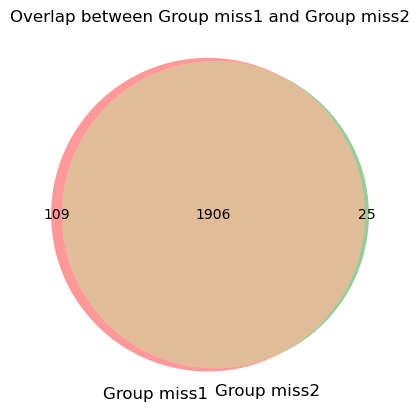

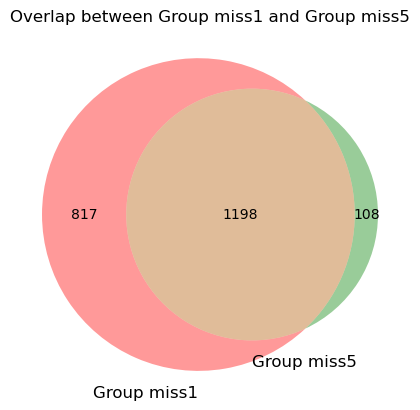

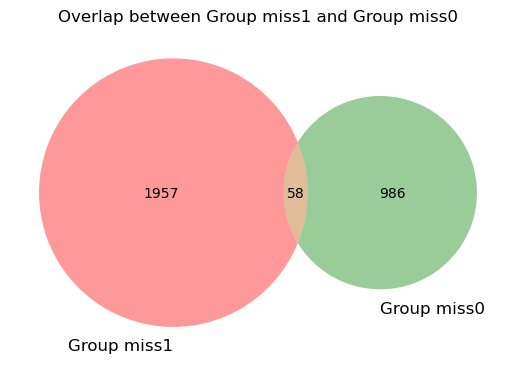

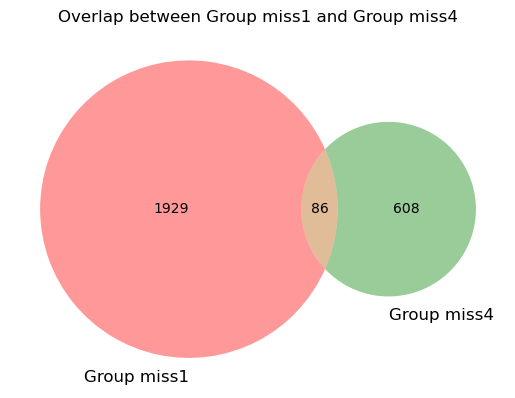

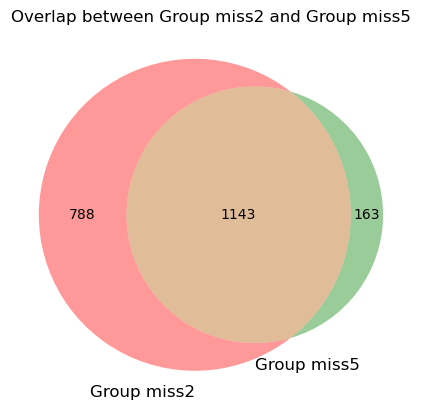

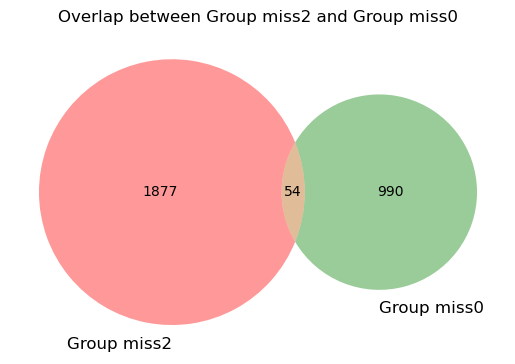

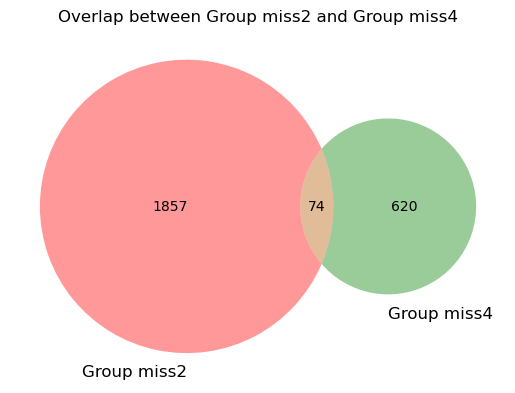

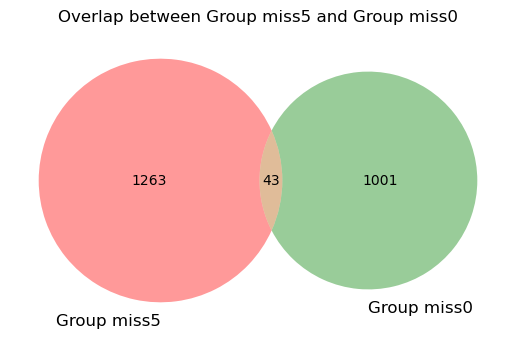

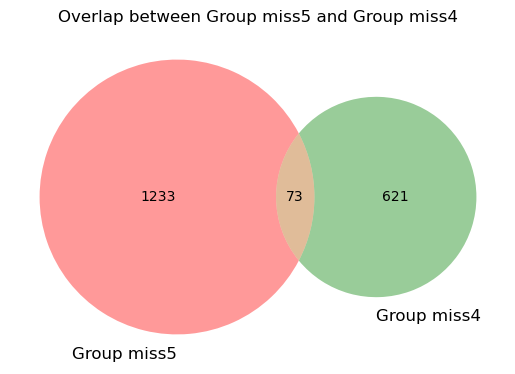

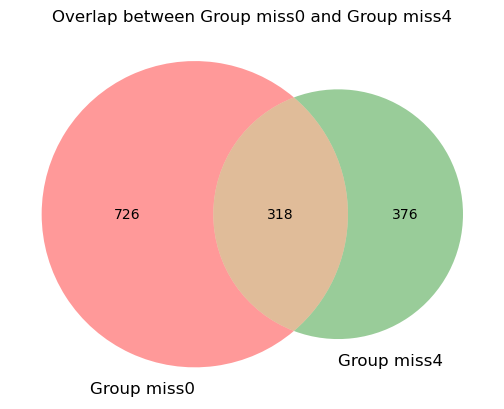

In [29]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import itertools

missingness_groups = list(fitbit.vendor.unique())

# Create a dictionary mapping each missingness group to its set of clients
group_clients = {
    group: set(fitbit[fitbit.vendor == group].public_client_id.unique())
    for group in missingness_groups
}

# Iterate through all pairwise combinations
for group1, group2 in itertools.combinations(missingness_groups, 2):
    set1 = group_clients[group1]
    set2 = group_clients[group2]
    
    plt.figure()
    venn2([set1, set2], set_labels=(f"Group {group1}", f"Group {group2}"))
    plt.title(f"Overlap between Group {group1} and Group {group2}")
    plt.show()

# Define a class for fitbit data processing and add different data cleaning methods

In [10]:
fitbit.weekday.unique()

array(['Sun', 'Thu', 'Wed', 'Mon', 'Tue', 'Fri', 'Sat'], dtype=object)

In [11]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

warnings.simplefilter("ignore")

class FitbitDataProcessor:
    weird_vendor_date = '2017-03'
    
    def __init__(self, name):
        self.fitbit = fitbit.copy()
        self.notes = []  # List to track method calls and parameters
        self.name = name
        
    def filter_by_time_difference(self, hours=3):
        """Remove sleep records that are within a given number of hours of each other."""
        self.notes.append(f"filter_by_time_difference called with hours={hours}")
        
        self.fitbit['sleep_timeStamp'] = self.fitbit.sleep_startTime.apply(lambda x: x.timestamp())
        self.fitbit['sleep_timeStamp'] = self.fitbit['sleep_timeStamp'] / 3600  # Convert seconds to hours
        
        # Sort by public_client_id, vendor, and sleep_timeStamp
        self.fitbit = self.fitbit.sort_values(by=['public_client_id', 'vendor', 'sleep_timeStamp'])
        
        # Calculate time differences within each group
        self.fitbit['time_diff_hours'] = (
            self.fitbit.groupby(['public_client_id', 'vendor'])['sleep_timeStamp']
            .diff()
        )
        
        # Get the indices of the rows that are within 3 hours of each other
        neighbor_indices = self.fitbit[
            (self.fitbit['time_diff_hours'] >= 0) & (self.fitbit['time_diff_hours'] <= 3)
        ].index.tolist()
        
        extended_indices = neighbor_indices + [i - 1 for i in neighbor_indices]
        
        # Remove rows that are within the specified time difference
        self.fitbit = self.fitbit.loc[~self.fitbit.index.isin(extended_indices)]
    
    def replace_outliers_iqr(self, columns, replace_zeroes):
        """Replace 0s with Nan and/or replace outliers using the IQR method with Nan"""
        self.notes.append(f"replace_outliers_iqr called with columns={columns}, replace_zeroes={replace_zeroes}")
        
        if replace_zeroes == True:
            for col in columns:
                # Replace zeros with NaN
                self.fitbit[col] = self.fitbit[col].replace(0, np.nan)
                
                # Replace outliers outside of IQR*1.5 w Nan
                Q1, Q3 = self.fitbit[col].quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
                self.fitbit[col] = self.fitbit[col][(self.fitbit[col] >= lower_bound) & (self.fitbit[col] <= upper_bound)]

        else:
            for col in columns:
                # Skip replacing 0s with Nan
                # Replace outliers outside of IQR*1.5 w Nan
                Q1, Q3 = self.fitbit[col].quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
                self.fitbit[col] = self.fitbit[col][(self.fitbit[col] >= lower_bound) & (self.fitbit[col] <= upper_bound)]

    def replace_outliers_iqr_by_vendor(self, columns, replace_zeroes):
        """
        Replace 0s with NaN (if specified) globally, and then replace outliers using the IQR method with NaN,
        calculating outliers separately for each vendor.
        
        Outliers are defined as values outside 1.5 * IQR (Interquartile Range)
        and will be replaced with np.nan calculated and applied to each vendor (rather 
        than globally, ie considering all vendors together).
        
        Parameters:
        - columns (list): List of column names to apply outlier removal.
        - replace_zeroes (bool): If True, replaces 0 values in the specified columns with np.nan before outlier detection.
        """
        
        self.notes.append(f"replace_outliers_iqr_by_vendor called with columns={columns}, replace_zeroes={replace_zeroes}")
        
        for col in columns:
            if replace_zeroes:
                # Replace zeros with NaN
                self.fitbit[col] = self.fitbit[col].replace(0, np.nan)
            
            # Process each vendor separately
            for vendor in self.fitbit['vendor'].unique():
                vendor_mask = self.fitbit['vendor'] == vendor
                vendor_values = self.fitbit.loc[vendor_mask, col]

                # Skip vendors with no valid data, for loop will go to next vendor if true
                if vendor_values.dropna().empty:
                    continue
    
                # Compute 1.5*IQR
                Q1, Q3 = vendor_values.quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
                # Replace outliers outside of IQR*1.5 with NaN (only for this vendor)
                self.fitbit.loc[vendor_mask, col] = vendor_values.mask(
                    (vendor_values < lower_bound) | (vendor_values > upper_bound),
                    np.nan
                )
        
    def filter_bedtime_hours(self, min_hour, max_hour):
        """
        Filter the Fitbit data to include only records within a given bedtime int range.
        Times between midnight and noon (ie 00:00-12:00) are treated as within the second day 
        (e.g., 01:00am → 24 + 1 = 25.0). So filtering to only include bedtimes between 5pm to 4am
        would be min_hour=17 and max_hour=28
        """
        self.notes.append(f"filter_bedtime_hours called with min_hour={min_hour}, max_hour={max_hour}")

        self.fitbit = self.fitbit[(self.fitbit['bedtime_int'] > min_hour) & (self.fitbit['bedtime_int'] < max_hour)]
    
    def drop_nulls(self, subset, any_or_all):
        """Specify subset of columns from which to drop Nans and specify how,
        ie drop whole row only if ALL values are nan or drop whole row if ANY values are nan
        """
        self.notes.append(f"drop_nulls called with subset of columns={subset}, any_or_all={any_or_all}")
        self.fitbit = self.fitbit.dropna(subset=subset, how=any_or_all)
    
    def plot_histograms(self):
        """Plot histograms for all sleep and activity features in a 4x5 grid."""
        fig, axes = plt.subplots(5, 4, figsize=(15, 20))
        axes = axes.flatten()
        
        for i, col in enumerate(sleep_and_activity_features):
            axis = axes[i]
            x = self.fitbit[col].dropna()
            mean, std = x.mean(), x.std()
            axis.hist(x, bins=50)
            axis.set_title(f'{col}\nMean = {round(mean, 2)}\nStd = {round(std, 2)}')
        
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        
        plt.tight_layout(rect=[-1, 0, 2, 3])
        plt.show()

    def merge_microbe(self, days_apart=15, features=sleep_and_activity_features, min_count=5):
        """
        inner merge all the fitbit and microbe together, this keeps only people with
        microbe and fitbit measures. Since this class is to look primarily at different data
        processing/cleaning schemes, only the public_client_id, vendor_observation_id, days_in_program
        and microbe_dip are saved to the df - this is to avoid unnecesarily large dataframes
        and computational cost. Microbe features df (measure_microbe) can easily be added to the df later
        by doing an inner merge matching on public_client_id.

        The multiple fitbit observations per person are collapsed/averaged on the first public_client_id's
        from the microbe features df (measure_microbe) - so public_client_id can be used as a matching key.
        """
        
        self.notes.append(f"merge_microbe called with days_apart={days_apart}, features=sleep_and_activity_features, min_count={min_count}")

        pre_agg_fitbit = pd.merge(measure_microbe[["public_client_id", "microbe_dip"]],
                          self.fitbit, on='public_client_id')
        
        # filter down to only rows where fitbit_dip is within +/- 15 days of microbe_dip
        pre_agg_fitbit = pre_agg_fitbit[(pre_agg_fitbit['fitbit_dip'] >= pre_agg_fitbit['microbe_dip'] - days_apart) & 
                               (pre_agg_fitbit['fitbit_dip'] <= pre_agg_fitbit['microbe_dip'] + days_apart)]
        
        def aggregate_with_vendor_check(df, agg_func_user_input='mean'):
            """
            Aggregates feature values for each 'public_client_id' based on the majority vendor while resolving ties.
            
            This function groups the data by 'public_client_id', selects the vendor with the most observations,
            and aggregates feature values accordingly. In case of a tie between vendors, it selects the one with 
            the fewest NaN values across the specified features. It also calculates a timestamp for 
            'microbe_dip' by using 'sleep_startTime'. I.e. you know that sleep_startTime, which is a date/time
            and not a relative number of days in program equals the fitbit_dip. Then you can see how far off
            microbe_dip is from fitbit_dip to get the date/time of microbe_dip.
        
            Parameters:
            ----------
            df :
                - 'public_client_id' (used for grouping)
                - 'vendor' (used for wearables vendor selection)
                - 'fitbit_dip', 'microbe_dip', 'sleep_startTime' (used for timestamp calculation)
                - Features listed in the `features` parameter, put in sleep_features + activity features.
        
            features : list of str
                List of column names representing the features to aggregate (put in sleep_features + activity_features).
        
            min_count : int, optional (default=5)
                The minimum number of non-NaN values required to compute a mean for each feature.
                If a feature has fewer non-NaN values than this threshold within the selected vendor, 
                the aggregated value will be set to NaN.
        
            Returns:
            -------
            aggregated_df :
                A df where each row corresponds to a unique 'public_client_id' with the following:
                - Aggregated feature values (mean per feature if above `min_count`, else NaN).
                - 'aggregated_vendor': The vendor chosen for aggregation.
                - 'microbe_date': The date for 'microbe_dip'.
                - 'reference_sleepStartTime': The sleep start time value used as a reference to calc microbe_date.
                - 'reference_microbe_dip': The original microbe dip value used to calc microbe_date.
                - 'reference_fitbit_dip': The original Fitbit dip value used as a reference to calc microbe_date.
        
            Notes:
            -----
            - The function resolves vendor ties based on the count of available feature values (favoring fewer NaNs).
            - If no vendor meets the criteria, the function returns NaNs for all features and 'aggregated_vendor'.
            - Timestamp adjustment for 'microbe_dip' is computed as:
              `sleep_startTime + (microbe_dip - fitbit_dip) days`.
            """
            
            # Define Aggregation Based on User Input
            agg_func_map = {
                "mean": lambda x: x.mean() if x.count() >= min_count else np.nan,
                "std": lambda x: x.std() if x.count() >= min_count else np.nan
                # Can add more aggregation functions here if you want
            }
            
            def agg_function(group):
                vendor_counts = group['vendor'].value_counts()
                
                # Identify majority vendor, breaking ties based on NaN counts if needed
                if len(vendor_counts) == 1:
                    # Only one vendor present
                    majority_vendor = vendor_counts.index[0]
                elif len(vendor_counts) > 1 and vendor_counts.values[0] == vendor_counts.values[1]:
                    # Tie between top vendors, select based on NaN count across features
                    tied_vendors = vendor_counts.index[:2]
                    
                    # Calculate NaN counts for each tied vendor across all features
                    nan_counts = {
                        vendor: group[group['vendor'] == vendor][features].isna().sum().sum()
                        for vendor in tied_vendors
                    }
                    # Select the vendor with the least NaN values, if there is a NaN count tie this will automatically
                    # select the first vendor in the dict
                    majority_vendor = min(nan_counts, key=nan_counts.get)
                else:
                    # No tie, pick the vendor with the most observations
                    majority_vendor = vendor_counts.index[0]
                
                # Aggregate features based on the majority vendor
                if majority_vendor is not None:
                    vendor_group = group[group['vendor'] == majority_vendor]
                    
                    # Define aggregation with per-feature threshold
                    #agg_dict = {
                    #    col: lambda x: x.mean() if x.count() >= min_count else np.nan
                    #    for col in features
                    #}
                    agg_dict = {col: agg_func_map[agg_func_user_input] for col in features}
                    
                    aggregated_data = vendor_group.agg(agg_dict)
                    aggregated_data['aggregated_vendor'] = majority_vendor  # Add vendor info
                    
                    # Add logic for calculating microbe_dip timestamp
                    reference_row = vendor_group.iloc[0]  # Use the topmost row of the group
                    reference_fitbit_dip = reference_row['fitbit_dip']
                    reference_sleep_startTime = pd.to_datetime(reference_row['sleep_startTime'])
                    
                    # Adjust the timestamp for microbe_dip
                    microbe_dip_timestamp = (
                        reference_sleep_startTime 
                        + pd.to_timedelta(reference_row['microbe_dip'] - reference_fitbit_dip, unit='D')
                    )
                    aggregated_data['microbe_date'] = microbe_dip_timestamp.date()
                    aggregated_data['reference_sleepStartTime'] = reference_sleep_startTime
                    aggregated_data['reference_microbe_dip'] = reference_row['microbe_dip']
                    aggregated_data['reference_fitbit_dip'] = reference_fitbit_dip

                    # ✅ Add most common season
                    season_mode = vendor_group['season'].mode()
                    aggregated_data['mode_season'] = season_mode.iloc[0] if not season_mode.empty else np.nan
        
                    # ✅ Add weekend-to-weekday ratio
                    # Note this paper calls WEEKENDS Friday Saturday and WEEKDAYS Sunday Monday:
                    # https://pmc.ncbi.nlm.nih.gov/articles/PMC3490026/
                    # Similarly this paper on the arivale fitbit data also found:
                    # https://www.nature.com/articles/ijo2017223
                    # The average mean sleep time was lowest on Monday night
                    # (meaning the sleeping time from Monday night to Tuesday morning)
                    # with 6.93 h. Then it gradually increased (6.97 h on Tuesday,
                    # 6.99 h on Wednesday, 7.02 h on Thursday, 7.44 h on Friday).
                    # After reaching the peak on Saturday night (7.51 h),
                    # the sleep duration dropped back down on Sunday night (7.06 h).
                    weekday_count = vendor_group['weekday'].isin(['Thu', 'Wed', 'Mon', 'Tue', 'Sun']).sum()
                    weekend_count = vendor_group['weekday'].isin(['Fri', 'Sat']).sum()
                    
                    weekend_weekday_ratio = (
                        weekend_count / weekday_count
                        if weekday_count > 0 else 1
                    )
                    aggregated_data['weekend_weekday_ratio'] = weekend_weekday_ratio
                    
                    return aggregated_data
                
                else:
                    # Return NaNs if no Majority_Vendor is found, including the vendor column
                    return pd.Series({col: np.nan for col in features + ['aggregated_vendor']})
        
            # Group by 'public_client_id' and apply the custom aggregation function
            aggregated_df = df.groupby('public_client_id').apply(agg_function).reset_index()
            
            return aggregated_df
        
        aggregated_avg_fitbit = aggregate_with_vendor_check(df=pre_agg_fitbit.copy(), agg_func_user_input='mean')
        aggregated_std_fitbit = aggregate_with_vendor_check(df=pre_agg_fitbit.copy(), agg_func_user_input='std')
        aggregated_std_fitbit = aggregated_std_fitbit[features + ['public_client_id']]
        aggregated_std_fitbit = aggregated_std_fitbit.rename(columns={col: f"{col}_std" for col in features})

        # Merge the mean and std data together
        print(f'length of aggregated_avg_fitbit: {len(aggregated_avg_fitbit)}')
        print(f'length of aggregated_std_fitbit: {len(aggregated_std_fitbit)}')
        aggregated_avg_std_fitbit = pd.merge(aggregated_avg_fitbit, aggregated_std_fitbit, on='public_client_id', how='inner')
        print(f'length of aggregated_avg_std_fitbit: {len(aggregated_avg_std_fitbit)}')

        self.fitbit = pd.merge(aggregated_avg_std_fitbit, measure_microbe[['public_client_id', 'days_in_program']],
                               on='public_client_id')
        self.fitbit = self.fitbit.sort_values(by="days_in_program")
        self.fitbit['vendor_weird_date'] = self.fitbit.reference_sleepStartTime.dt.to_period('M') < self.__class__.weird_vendor_date
    
    def merge_covariates(self, days_apart=30.0):
        """
        Merge sex, age, BMI, and first 3 PC of ancestry onto 
        `self.fitbit` based on `public_client_id` and `days_in_program`.
        Days_apart is comparing days_in_program from covariate entries to days_in_program
        of microbe entries.
        """
        self.notes.append(f"merge_covariates called with days_apart={days_apart}")
    
        # Ensure fitbit_microbe exists before merging
        if not hasattr(self, "fitbit"):
            raise AttributeError("self.fitbit is not defined. Run merge_microbe() first.")
    
        # Merge ancestry weights onto fitbit_microbe
        self.fitbit = pd.merge_asof(
            self.fitbit,
            clients_ancestry_weights[
                clients_ancestry_weights.public_client_id.isin(self.fitbit.public_client_id)
            ],
            by="public_client_id",
            on="days_in_program",
            direction="nearest",
            tolerance=days_apart
        )
    
        # Drop any rows where covariate merge out of days apart tolerance
        self.fitbit = self.fitbit.dropna(subset=['weights_dip'])

    def save_fitbit_with_notes(self):
        """Save Fitbit data with notes in the same directory using instance name and today's date."""
        # Get today's date in YYYY-MM-DD format
        today_date = datetime.today().strftime("%Y-%m-%d")
    
        # Generate a filename using self.name and today's date
        filename = f"{self.name}_{today_date}.csv"
    
        # Store notes in the first row, all other rows are NaN
        notes_col = [" | ".join(self.notes)] + [np.nan] * (len(self.fitbit) - 1)
        self.fitbit["processing_notes"] = notes_col  
    
        # Save to CSV in the same directory
        self.fitbit.to_csv(filename, index=False)
    
        print(f"Saved file: {filename}")

# Define different data cleaning and merging

In [62]:
# Scheme 0
# no data processing/cleaning
# just dropped nan in sleep_startTime, public_client_id, or days_in_program (see cells above class definition)
# also only observations w days_in_program >= 0
fitbit_noProcessing = FitbitDataProcessor('scheme0_fitbit_noProcessing')
fitbit_noProcessing.merge_microbe()
fitbit_noProcessing.merge_covariates()
fitbit_noProcessing.save_fitbit_with_notes()

# Scheme 1
# replace sleep_and_activity_features 0s with Nan and replace outliers outside 1.5*IQR w Nan
# then drop rows with any Nan in activity_features
# note, this is the cleaning scheme I've been using up through end of 2024
fitbit_cleanSleepAndActivity_standard = FitbitDataProcessor('scheme1_fitbit_cleanSleepAndActivity_standard')
fitbit_cleanSleepAndActivity_standard.replace_outliers_iqr(sleep_and_activity_features, replace_zeroes=True)
fitbit_cleanSleepAndActivity_standard.merge_microbe()
fitbit_cleanSleepAndActivity_standard.merge_covariates()
fitbit_cleanSleepAndActivity_standard.drop_nulls(subset=activity_features, any_or_all='any')
fitbit_cleanSleepAndActivity_standard.save_fitbit_with_notes()

# Scheme 2
# drop rows with sleep_minutesToFallAsleep outliers, defined as outside 1.5*IQR.
# note that these values should almost always be 0 according to:
# https://enterprise.fitbit.com/wp-content/uploads/Fitbit-Web-API-Data-Dictionary-Downloadable-Version-2023.pdf
fitbit_dropOutlierMinutesToFallAsleep = FitbitDataProcessor('scheme2_fitbit_dropOutlierMinutesToFallAsleep')
fitbit_dropOutlierMinutesToFallAsleep.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_dropOutlierMinutesToFallAsleep.drop_nulls(subset=['sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_dropOutlierMinutesToFallAsleep.merge_microbe()
fitbit_dropOutlierMinutesToFallAsleep.merge_covariates()
fitbit_dropOutlierMinutesToFallAsleep.save_fitbit_with_notes()

# Scheme 3
# drop rows with bedtime_int outliers, defined as outside 1.5*IQR.
fitbit_dropOutlierBedtimes = FitbitDataProcessor('scheme3_fitbit_dropOutlierBedtimes')
fitbit_dropOutlierBedtimes.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_dropOutlierBedtimes.drop_nulls(subset=['bedtime_int'], any_or_all='any')
fitbit_dropOutlierBedtimes.merge_microbe()
fitbit_dropOutlierBedtimes.merge_covariates()
fitbit_dropOutlierBedtimes.save_fitbit_with_notes()

# Scheme 4
# drop rows where an individual public client id has fitbit observations within 3 hours of each other
fitbit_dropCloseObservations3hrs = FitbitDataProcessor('scheme4_fitbit_dropCloseObservations3hrs')
fitbit_dropCloseObservations3hrs.filter_by_time_difference(hours=3)
fitbit_dropCloseObservations3hrs.merge_microbe()
fitbit_dropCloseObservations3hrs.merge_covariates()
fitbit_dropCloseObservations3hrs.save_fitbit_with_notes()

# Scheme 5
# first independently replace outliers in bedtime_int and sleep_minutesToFallAsleep
# with nan as in Schemes 2 and 3. Then drop rows with nan in either bedtime_int 
# and/or sleep_minutesToFallAsleep. Finally, drop rows like in scheme 4
# where an individual public client id has fitbit observations within
# 3 hours of each other
fitbit_cleaningSchemeTwoToFour = FitbitDataProcessor('scheme5_fitbit_cleaningSchemeTwoToFour')
fitbit_cleaningSchemeTwoToFour.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cleaningSchemeTwoToFour.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_cleaningSchemeTwoToFour.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_cleaningSchemeTwoToFour.filter_by_time_difference(hours=3)
fitbit_cleaningSchemeTwoToFour.merge_microbe()
fitbit_cleaningSchemeTwoToFour.merge_covariates()
fitbit_cleaningSchemeTwoToFour.save_fitbit_with_notes()

Saved file: scheme0_fitbit_noProcessing_2025-01-27.csv
Saved file: scheme1_fitbit_cleanSleepAndActivity_standard_2025-01-27.csv
Saved file: scheme2_fitbit_dropOutlierMinutesToFallAsleep_2025-01-27.csv
Saved file: scheme3_fitbit_dropOutlierBedtimes_2025-01-27.csv
Saved file: scheme4_fitbit_dropCloseObservations3hrs_2025-01-27.csv
Saved file: scheme5_fitbit_cleaningSchemeTwoToFour_2025-01-27.csv


In [48]:
# Scheme 6
# Same as scheme 5, except first drop observations part 
# of that second mode that appears in hapi-fitbit after 2017-03
fitbit_cleaningSchemeFiveAndDropLessTotalMin = FitbitDataProcessor('scheme6_fitbit_cleaningSchemeFiveAndDropLessTotalMin')

# make a total_min column
fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit['total_min'] = fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit[fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit[(fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit.vendor == 'hapi-fitbit') & (fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
# Now only keep rows where total min is above the lower bound ie this is dropping rows that make up that second mode
fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit = fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit[
    fitbit_cleaningSchemeFiveAndDropLessTotalMin.fitbit.total_min >= lower_bound
]
# Add a note of dropping the first lower mode in the fitbit df where vendor is hapi-fitbit
fitbit_cleaningSchemeFiveAndDropLessTotalMin.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff to drop second lower mode of total min rows')
# Now do the cleaning scheme 5
fitbit_cleaningSchemeFiveAndDropLessTotalMin.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cleaningSchemeFiveAndDropLessTotalMin.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_cleaningSchemeFiveAndDropLessTotalMin.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_cleaningSchemeFiveAndDropLessTotalMin.filter_by_time_difference(hours=3)
fitbit_cleaningSchemeFiveAndDropLessTotalMin.merge_microbe()
fitbit_cleaningSchemeFiveAndDropLessTotalMin.merge_covariates()
fitbit_cleaningSchemeFiveAndDropLessTotalMin.save_fitbit_with_notes()

Saved file: scheme6_fitbit_cleaningSchemeFiveAndDropLessTotalMin_2025-01-31.csv


In [33]:
# Scheme 7
# Same as scheme 6, just the order of cleaning steps flipped
# so do the scheme 5 cleaning first and then drop the total_min second mode
fitbit_cleaningSchemeSixFlipped = FitbitDataProcessor('scheme7_fitbit_cleaningSchemeSixFlipped')

# Do the cleaning scheme 5
fitbit_cleaningSchemeSixFlipped.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cleaningSchemeSixFlipped.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_cleaningSchemeSixFlipped.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_cleaningSchemeSixFlipped.filter_by_time_difference(hours=3)

# make a total_min column
fitbit_cleaningSchemeSixFlipped.fitbit['total_min'] = fitbit_cleaningSchemeSixFlipped.fitbit[fitbit_cleaningSchemeSixFlipped.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_cleaningSchemeSixFlipped.fitbit[(fitbit_cleaningSchemeSixFlipped.fitbit.vendor == 'hapi-fitbit') & (fitbit_cleaningSchemeSixFlipped.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
# Now only keep rows where total min is above the lower bound ie this is dropping rows that make up that second mode
fitbit_cleaningSchemeSixFlipped.fitbit = fitbit_cleaningSchemeSixFlipped.fitbit[
    fitbit_cleaningSchemeSixFlipped.fitbit.total_min >= lower_bound
]
# Add a note of dropping the first lower mode in the fitbit df where vendor is hapi-fitbit
fitbit_cleaningSchemeSixFlipped.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff to drop second lower mode of total min rows')

fitbit_cleaningSchemeSixFlipped.merge_microbe()
fitbit_cleaningSchemeSixFlipped.merge_covariates()
fitbit_cleaningSchemeSixFlipped.save_fitbit_with_notes()

Saved file: scheme7_fitbit_cleaningSchemeSixFlipped_2025-01-31.csv


In [34]:
# Scheme 8
# Same as scheme 7, just first drop rows where vendor is NOT hapi-fitbit or FitBit
fitbit_cleaningScheme7Only2Vendor = FitbitDataProcessor('scheme8_fitbit_cleaningScheme7ButOnly2Vendor')
fitbit_cleaningScheme7Only2Vendor.fitbit = fitbit_cleaningScheme7Only2Vendor.fitbit[(fitbit_cleaningScheme7Only2Vendor.fitbit.vendor == 'FitBit') | (fitbit_cleaningScheme7Only2Vendor.fitbit.vendor == 'hapi-fitbit')]
fitbit_cleaningScheme7Only2Vendor.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit')


# Do the cleaning scheme 5
fitbit_cleaningScheme7Only2Vendor.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cleaningScheme7Only2Vendor.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_cleaningScheme7Only2Vendor.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_cleaningScheme7Only2Vendor.filter_by_time_difference(hours=3)

# make a total_min column
fitbit_cleaningScheme7Only2Vendor.fitbit['total_min'] = fitbit_cleaningScheme7Only2Vendor.fitbit[fitbit_cleaningScheme7Only2Vendor.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_cleaningScheme7Only2Vendor.fitbit[(fitbit_cleaningScheme7Only2Vendor.fitbit.vendor == 'hapi-fitbit') & (fitbit_cleaningScheme7Only2Vendor.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
# Now only keep rows where total min is above the lower bound ie this is dropping rows that make up that second mode
fitbit_cleaningScheme7Only2Vendor.fitbit = fitbit_cleaningScheme7Only2Vendor.fitbit[
    fitbit_cleaningScheme7Only2Vendor.fitbit.total_min >= lower_bound
]
# Add a note of dropping the first lower mode in the fitbit df where vendor is hapi-fitbit
fitbit_cleaningScheme7Only2Vendor.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff to drop second lower mode of total min rows')

fitbit_cleaningScheme7Only2Vendor.merge_microbe()
fitbit_cleaningScheme7Only2Vendor.merge_covariates()
fitbit_cleaningScheme7Only2Vendor.save_fitbit_with_notes()

Saved file: scheme8_fitbit_cleaningScheme7ButOnly2Vendor_2025-01-31.csv


In [79]:
# Scheme 9
# First drop observations NOT vendor == FitBit, hapi-fitbit, or hapi-fitbit2 (like scheme 8 above).
# Note, this is using the NEW VENDOR COLUMN, where i've turned observations vendor==hapi-fitbit with
# sleep_minutesAsleep null into hapi-fitbit2.
# Then do cleaning scheme 5, where you drop minutesToFallAsleep and bedtime outliers, then also drop
# observations that are within the same night, ie 3 hours apart

# The first part of cleaning scheme 8
fitbit_cleaningScheme8and5 = FitbitDataProcessor('scheme9_fitbit_cleaningScheme8and5')
fitbit_cleaningScheme8and5.fitbit = fitbit_cleaningScheme8and5.fitbit[(fitbit_cleaningScheme8and5.fitbit.vendor == 'FitBit') | (fitbit_cleaningScheme8and5.fitbit.vendor == 'hapi-fitbit') | (fitbit_cleaningScheme8and5.fitbit.vendor == 'hapi-fitbit2')]
fitbit_cleaningScheme8and5.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit or hapi-fitbit2')

# Do the cleaning scheme 5
fitbit_cleaningScheme8and5.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cleaningScheme8and5.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_cleaningScheme8and5.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_cleaningScheme8and5.filter_by_time_difference(hours=3)

fitbit_cleaningScheme8and5.merge_microbe()
fitbit_cleaningScheme8and5.merge_covariates()
fitbit_cleaningScheme8and5.save_fitbit_with_notes()

Saved file: scheme9_fitbit_cleaningScheme8and5_2025-02-03.csv


In [205]:
# Scheme 10
# First start the same as cleaning scheme 8, which showed the most microbe hits and high agreement w questionnaire.
fitbit_considerVendorsSeparately = FitbitDataProcessor('scheme10_fitbit_considerVendorsSeparately')
fitbit_considerVendorsSeparately.fitbit = fitbit_considerVendorsSeparately.fitbit[(fitbit_considerVendorsSeparately.fitbit.vendor == 'FitBit') | (fitbit_considerVendorsSeparately.fitbit.vendor == 'hapi-fitbit')]
fitbit_considerVendorsSeparately.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit')

# Now update the vendor column to define the second hapi-fitbit distribution
# make a total_min column
fitbit_considerVendorsSeparately.fitbit['total_min'] = fitbit_considerVendorsSeparately.fitbit[fitbit_considerVendorsSeparately.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_considerVendorsSeparately.fitbit[(fitbit_considerVendorsSeparately.fitbit.vendor == 'hapi-fitbit') & (fitbit_considerVendorsSeparately.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

# Create new column 'vendor_updated' so that the second hapi-fitbit distribution has its own label
fitbit_considerVendorsSeparately.fitbit['vendor'] = fitbit_considerVendorsSeparately.fitbit.vendor.mask(
    (fitbit_considerVendorsSeparately.fitbit.vendor == 'hapi-fitbit') & (fitbit_considerVendorsSeparately.fitbit.sleep_minutesAsleep.isna()),
    'hapi-fitbit2'
)

# Now cleanup the leftover first hapi-fitbit distribution
# only keep rows where hapi-fitbit leftover distribution is greater than or equal to
# the lower bound of the hapi-fitbit distribution before 2017-03 
fitbit_considerVendorsSeparately.fitbit = fitbit_considerVendorsSeparately.fitbit[~((fitbit_considerVendorsSeparately.fitbit.vendor == 'hapi-fitbit') & (fitbit_considerVendorsSeparately.fitbit.total_min < lower_bound))]

# Add a note of defining the second hapi-fitbit distribution and cleaning up the
# the leftover first distribution in hapi-fitbit
fitbit_considerVendorsSeparately.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff. Then define the second distribution, ie if you are hapi-fitbit and have all nulls in minutesAsleep. Then go back and clean up original leftover first hapi-fitbit distribution using before 2017-03 cutoff.')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_considerVendorsSeparately.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_considerVendorsSeparately.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_considerVendorsSeparately.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_considerVendorsSeparately.filter_by_time_difference(hours=3)

fitbit_considerVendorsSeparately.merge_microbe()
fitbit_considerVendorsSeparately.merge_covariates()
fitbit_considerVendorsSeparately.save_fitbit_with_notes()

Saved file: scheme10_fitbit_considerVendorsSeparately_2025-02-04.csv


In [242]:
# Scheme 11
# Same as scheme 10, but clean up the sleep and activity columns
fitbit_cleaningScheme10WOutlierCleanUpColumns = FitbitDataProcessor('scheme11_fitbit_cleaningScheme10WOutlierCleanUpColumns')
fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit = fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit[(fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.vendor == 'FitBit') | (fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.vendor == 'hapi-fitbit')]
fitbit_cleaningScheme10WOutlierCleanUpColumns.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit')

# Now update the vendor column to define the second hapi-fitbit distribution
# make a total_min column
fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit['total_min'] = fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit[fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit[(fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.vendor == 'hapi-fitbit') & (fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

# Create new column 'vendor_updated' so that the second hapi-fitbit distribution has its own label
fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit['vendor'] = fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.vendor.mask(
    (fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.vendor == 'hapi-fitbit') & (fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.sleep_minutesAsleep.isna()),
    'hapi-fitbit2'
)

# Now cleanup the leftover first hapi-fitbit distribution
# only keep rows where hapi-fitbit leftover distribution is greater than or equal to
# the lower bound of the hapi-fitbit distribution before 2017-03 
fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit = fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit[~((fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.vendor == 'hapi-fitbit') & (fitbit_cleaningScheme10WOutlierCleanUpColumns.fitbit.total_min < lower_bound))]

# Add a note of defining the second hapi-fitbit distribution and cleaning up the
# the leftover first distribution in hapi-fitbit
fitbit_cleaningScheme10WOutlierCleanUpColumns.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff. Then define the second distribution, ie if you are hapi-fitbit and have all nulls in minutesAsleep. Then go back and clean up original leftover first hapi-fitbit distribution using before 2017-03 cutoff.')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_cleaningScheme10WOutlierCleanUpColumns.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cleaningScheme10WOutlierCleanUpColumns.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)

# This is where it differs from scheme 10, first replace outliers in sleep and activity columns
# and then drop the nulls in minutesToFallAsleep and bedtime_int
fitbit_cleaningScheme10WOutlierCleanUpColumns.replace_outliers_iqr_by_vendor(['sleep_efficiency',
                                                                             'sleep_minutesAsleep',
                                                                             'sleep_timeInBed',
                                                                             'activities_activityCalories',
                                                                             'activities_calories',
                                                                             'activities_distance',
                                                                             'activities_elevation',
                                                                             'activities_floors',
                                                                             'activities_steps'], replace_zeroes=True)
fitbit_cleaningScheme10WOutlierCleanUpColumns.replace_outliers_iqr_by_vendor(['sleep_awakeDuration',
                                                                             'sleep_awakeningsCount',
                                                                             'sleep_minutesAfterWakeup',
                                                                              'sleep_minutesAwake',
                                                                              'sleep_restlessDuration',
                                                                               'activities_minutesFairlyActive',
                                                                             'activities_minutesLightlyActive',
                                                                             'activities_minutesSedentary',
                                                                             'activities_minutesVeryActive'], replace_zeroes=False)
fitbit_cleaningScheme10WOutlierCleanUpColumns.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_cleaningScheme10WOutlierCleanUpColumns.filter_by_time_difference(hours=3)


fitbit_cleaningScheme10WOutlierCleanUpColumns.merge_microbe()
fitbit_cleaningScheme10WOutlierCleanUpColumns.merge_covariates()
fitbit_cleaningScheme10WOutlierCleanUpColumns.save_fitbit_with_notes()

Saved file: scheme11_fitbit_cleaningScheme10WOutlierCleanUpColumns_2025-02-04.csv


In [308]:
# Scheme 12
# Exactly the same as scheme 10 but rows outside of total_min IQR for each vendor
fitbit_scheme10DropOutliersTotalMin = FitbitDataProcessor('scheme12_fitbit_scheme10DropOutliersTotalMin')
fitbit_scheme10DropOutliersTotalMin.fitbit = fitbit_scheme10DropOutliersTotalMin.fitbit[(fitbit_scheme10DropOutliersTotalMin.fitbit.vendor == 'FitBit') | (fitbit_scheme10DropOutliersTotalMin.fitbit.vendor == 'hapi-fitbit')]
fitbit_scheme10DropOutliersTotalMin.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit')

# Now update the vendor column to define the second hapi-fitbit distribution
# make a total_min column
fitbit_scheme10DropOutliersTotalMin.fitbit['total_min'] = fitbit_scheme10DropOutliersTotalMin.fitbit[fitbit_scheme10DropOutliersTotalMin.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_scheme10DropOutliersTotalMin.fitbit[(fitbit_scheme10DropOutliersTotalMin.fitbit.vendor == 'hapi-fitbit') & (fitbit_scheme10DropOutliersTotalMin.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

# Create new column 'vendor_updated' so that the second hapi-fitbit distribution has its own label
fitbit_scheme10DropOutliersTotalMin.fitbit['vendor'] = fitbit_scheme10DropOutliersTotalMin.fitbit.vendor.mask(
    (fitbit_scheme10DropOutliersTotalMin.fitbit.vendor == 'hapi-fitbit') & (fitbit_scheme10DropOutliersTotalMin.fitbit.sleep_minutesAsleep.isna()),
    'hapi-fitbit2'
)

# Now cleanup the leftover first hapi-fitbit distribution
# only keep rows where hapi-fitbit leftover distribution is greater than or equal to
# the lower bound of the hapi-fitbit distribution before 2017-03 
fitbit_scheme10DropOutliersTotalMin.fitbit = fitbit_scheme10DropOutliersTotalMin.fitbit[~((fitbit_scheme10DropOutliersTotalMin.fitbit.vendor == 'hapi-fitbit') & (fitbit_scheme10DropOutliersTotalMin.fitbit.total_min < lower_bound))]

# Add a note of defining the second hapi-fitbit distribution and cleaning up the
# the leftover first distribution in hapi-fitbit
fitbit_scheme10DropOutliersTotalMin.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff. Then define the second distribution, ie if you are hapi-fitbit and have all nulls in minutesAsleep. Then go back and clean up original leftover first hapi-fitbit distribution using before 2017-03 cutoff.')

# Same as scheme 10, but also find outliers per vendor for total_min and drop null rows
# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_scheme10DropOutliersTotalMin.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_scheme10DropOutliersTotalMin.replace_outliers_iqr_by_vendor(['bedtime_int', 'total_min'], replace_zeroes=True)
fitbit_scheme10DropOutliersTotalMin.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int', 'total_min'], any_or_all='any')
fitbit_scheme10DropOutliersTotalMin.filter_by_time_difference(hours=3)

fitbit_scheme10DropOutliersTotalMin.merge_microbe()
fitbit_scheme10DropOutliersTotalMin.merge_covariates()
fitbit_scheme10DropOutliersTotalMin.save_fitbit_with_notes()

Saved file: scheme12_fitbit_scheme10DropOutliersTotalMin_2025-02-04.csv


In [6]:
# Scheme 13
# Exactly the same as scheme 10, but find IQR by vendor for minutesAsleep and drop those rows
fitbit_scheme10ButIqrVendorMinAsleep = FitbitDataProcessor('scheme13_fitbit_scheme10ButIqrVendorMinAsleep')
fitbit_scheme10ButIqrVendorMinAsleep.fitbit = fitbit_scheme10ButIqrVendorMinAsleep.fitbit[(fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor == 'FitBit') | (fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor == 'hapi-fitbit')]
fitbit_scheme10ButIqrVendorMinAsleep.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit')

# Now update the vendor column to define the second hapi-fitbit distribution
# make a total_min column
fitbit_scheme10ButIqrVendorMinAsleep.fitbit['total_min'] = fitbit_scheme10ButIqrVendorMinAsleep.fitbit[fitbit_scheme10ButIqrVendorMinAsleep.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_scheme10ButIqrVendorMinAsleep.fitbit[(fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor == 'hapi-fitbit') & (fitbit_scheme10ButIqrVendorMinAsleep.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

# Create new column 'vendor_updated' so that the second hapi-fitbit distribution has its own label
fitbit_scheme10ButIqrVendorMinAsleep.fitbit['vendor'] = fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor.mask(
    (fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor == 'hapi-fitbit') & (fitbit_scheme10ButIqrVendorMinAsleep.fitbit.sleep_minutesAsleep.isna()),
    'hapi-fitbit2'
)

# Now cleanup the leftover first hapi-fitbit distribution
# only keep rows where hapi-fitbit leftover distribution is greater than or equal to
# the lower bound of the hapi-fitbit distribution before 2017-03 
fitbit_scheme10ButIqrVendorMinAsleep.fitbit = fitbit_scheme10ButIqrVendorMinAsleep.fitbit[~((fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor == 'hapi-fitbit') & (fitbit_scheme10ButIqrVendorMinAsleep.fitbit.total_min < lower_bound))]

# Add a note of defining the second hapi-fitbit distribution and cleaning up the
# the leftover first distribution in hapi-fitbit
fitbit_scheme10ButIqrVendorMinAsleep.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff. Then define the second distribution, ie if you are hapi-fitbit and have all nulls in minutesAsleep. Then go back and clean up original leftover first hapi-fitbit distribution using before 2017-03 cutoff.')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_scheme10ButIqrVendorMinAsleep.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_scheme10ButIqrVendorMinAsleep.replace_outliers_iqr_by_vendor(['bedtime_int', 'sleep_minutesAsleep'], replace_zeroes=True)
fitbit_scheme10ButIqrVendorMinAsleep.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
# NOTE can't drop sleep_minutesAsleep nulls w the drop_nulls method bc it doesn't consider by vendor
# and the hapi-fitbit2 rows are ALL sleep_minutesAsleep null. So manually find NON hapi-fitbit2 rows
# here and drop if they have null in sleep_minutesAsleep, then add a note
fitbit_scheme10ButIqrVendorMinAsleep.fitbit[fitbit_scheme10ButIqrVendorMinAsleep.fitbit.vendor != 'hapi-fitbit2'].dropna(subset=['sleep_minutesAsleep'], inplace=True)
fitbit_scheme10ButIqrVendorMinAsleep.notes.append('dropped minutesAsleep null rows where vendor was NOT hapi-fitbit2')

fitbit_scheme10ButIqrVendorMinAsleep.filter_by_time_difference(hours=3)

fitbit_scheme10ButIqrVendorMinAsleep.merge_microbe()
fitbit_scheme10ButIqrVendorMinAsleep.merge_covariates()
fitbit_scheme10ButIqrVendorMinAsleep.save_fitbit_with_notes()

Saved file: scheme13_fitbit_scheme10ButIqrVendorMinAsleep_2025-02-05.csv


In [ ]:
# Scheme 14
# Same as schemes 8 and 10 but instead of just making 3 vendors, FitBit, hapi-fitbit, and hapi-fitbit2
# make 4 vendors, Fitbit, hapi-fitbit before 2017-3, hapi-fitbit after 2017-3, and hapi-fitbit2
fitbit_like8and10W3Vendors = FitbitDataProcessor('scheme14_fitbit_like8and10W3Vendors')
fitbit_like8and10W3Vendors.fitbit = fitbit_like8and10W3Vendors.fitbit[(fitbit_like8and10W3Vendors.fitbit.vendor == 'FitBit') | (fitbit_like8and10W3Vendors.fitbit.vendor == 'hapi-fitbit')]
fitbit_like8and10W3Vendors.notes.append('only keep rows where vendor == Fitbit or hapi-fitbit')

# Now update the vendor column to define the second hapi-fitbit distribution
# make a total_min column
fitbit_like8and10W3Vendors.fitbit['total_min'] = fitbit_like8and10W3Vendors.fitbit[fitbit_like8and10W3Vendors.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_like8and10W3Vendors.fitbit[(fitbit_like8and10W3Vendors.fitbit.vendor == 'hapi-fitbit') & (fitbit_like8and10W3Vendors.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

# First identify the hapi-fitbit rows before or on 2017-03
fitbit_like8and10W3Vendors.fitbit['vendor'] = fitbit_like8and10W3Vendors.fitbit.vendor.mask(
    (fitbit_like8and10W3Vendors.fitbit.vendor == 'hapi-fitbit') & (fitbit_like8and10W3Vendors.fitbit.sleep_date <= pd.to_datetime('2017-03').date()),
    'hapi-fitbit-before'
)

# Create new column 'vendor_updated' so that the second hapi-fitbit distribution has its own label
fitbit_like8and10W3Vendors.fitbit['vendor'] = fitbit_like8and10W3Vendors.fitbit.vendor.mask(
    (fitbit_like8and10W3Vendors.fitbit.vendor == 'hapi-fitbit') & (fitbit_like8and10W3Vendors.fitbit.sleep_minutesAsleep.isna()),
    'hapi-fitbit2'
)

# Now find the remaining 

# Now cleanup the leftover first hapi-fitbit distribution
# only keep rows where hapi-fitbit leftover distribution is greater than or equal to
# the lower bound of the hapi-fitbit distribution before 2017-03 
fitbit_like8and10W3Vendors.fitbit = fitbit_like8and10W3Vendors.fitbit[~((fitbit_considerVendorsSeparately.fitbit.vendor == 'hapi-fitbit') & (fitbit_considerVendorsSeparately.fitbit.total_min < lower_bound))]

# Add a note of defining the second hapi-fitbit distribution and cleaning up the
# the leftover first distribution in hapi-fitbit
fitbit_considerVendorsSeparately.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at hapi-fitbit only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff. Then define the second distribution, ie if you are hapi-fitbit and have all nulls in minutesAsleep. Then go back and clean up original leftover first hapi-fitbit distribution using before 2017-03 cutoff.')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_considerVendorsSeparately.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_considerVendorsSeparately.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_considerVendorsSeparately.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_considerVendorsSeparately.filter_by_time_difference(hours=3)

fitbit_considerVendorsSeparately.merge_microbe()
fitbit_considerVendorsSeparately.merge_covariates()
fitbit_considerVendorsSeparately.save_fitbit_with_notes()

### Below are cleaning schemes AFTER defining the data-driven missingness patterns.

In [256]:
# Scheme 14
# don't do any adjustments just merge the dfs w/ the new missingness vendor already defined above
# same as scheme 0 just w new vendor

fitbit_missingnessVendor = FitbitDataProcessor('scheme14_fitbit_missingnessVendor')
fitbit_missingnessVendor.merge_microbe()
fitbit_missingnessVendor.merge_covariates()
fitbit_missingnessVendor.save_fitbit_with_notes()

Saved file: scheme14_fitbit_missingnessVendor_2025-02-06.csv


In [257]:
# Scheme 15
# Same as schemes 14 and the end of scheme 10
fitbit_missingnessVendorAnd10 = FitbitDataProcessor('scheme15_fitbit_missingnessVendorAnd10')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_missingnessVendorAnd10.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_missingnessVendorAnd10.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_missingnessVendorAnd10.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_missingnessVendorAnd10.filter_by_time_difference(hours=3)

fitbit_missingnessVendorAnd10.merge_microbe()
fitbit_missingnessVendorAnd10.merge_covariates()
fitbit_missingnessVendorAnd10.save_fitbit_with_notes()

Saved file: scheme15_fitbit_missingnessVendorAnd10_2025-02-06.csv


In [127]:
# Scheme 16
# Same as scheme 10 but drop missingness groups 1, since these have bimodal total time
fitbit_dropMissGroup1and5 = FitbitDataProcessor('scheme16_fitbit_dropMissGroup1and5')
fitbit_dropMissGroup1and5.fitbit = fitbit_dropMissGroup1and5.fitbit[~fitbit_dropMissGroup1and5.fitbit.vendor.isin(['miss1', 'miss5'])]
fitbit_dropMissGroup1and5.notes.append('only keep rows where missingness group (ie vendor) != miss1 or miss5')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_dropMissGroup1and5.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
#fitbit_dropMissGroup1and5.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_dropMissGroup1and5.drop_nulls(subset=['sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_dropMissGroup1and5.filter_by_time_difference(hours=3)

fitbit_dropMissGroup1and5.merge_microbe()
fitbit_dropMissGroup1and5.merge_covariates()
fitbit_dropMissGroup1and5.save_fitbit_with_notes()

Saved file: scheme16_fitbit_dropMissGroup1and5_2025-02-21.csv


In [30]:
# Scheme 17
# First look at groups 1 and 5 and get rid of observations where total min < 1200, then aggregate by missingness group
fitbit_removeLowTotalMin = FitbitDataProcessor('scheme17_fitbit_removeLowTotalMin')
fitbit_removeLowTotalMin.fitbit['total_min'] = fitbit_removeLowTotalMin.fitbit[fitbit_removeLowTotalMin.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_removeLowTotalMin.fitbit = fitbit_removeLowTotalMin.fitbit[
    ((fitbit_removeLowTotalMin.fitbit["vendor"].isin(["miss1", "miss5"])) & (fitbit_removeLowTotalMin.fitbit["total_min"] >= 1200)) |
    (~fitbit_removeLowTotalMin.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_removeLowTotalMin.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_removeLowTotalMin.notes.append('drop rows in miss1 and miss5 where total min is less than 1200, then drop total min column')

# Continue like scheme 5, except this time find outliers for each vendor separately
fitbit_removeLowTotalMin.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_removeLowTotalMin.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_removeLowTotalMin.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_removeLowTotalMin.filter_by_time_difference(hours=3)

fitbit_removeLowTotalMin.merge_microbe()
fitbit_removeLowTotalMin.merge_covariates()
fitbit_removeLowTotalMin.save_fitbit_with_notes()

Saved file: scheme17_fitbit_removeLowTotalMin_2025-02-22.csv


In [80]:
# Scheme 18
# Same as scheme 17 just switch order, so replace outliers first and then drop low total min
fitbit_sameAs17Flipped = FitbitDataProcessor('scheme18_fitbit_sameAs17Flipped')

# Same as 17 just do this part first instead of second
fitbit_sameAs17Flipped.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_sameAs17Flipped.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_sameAs17Flipped.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_sameAs17Flipped.filter_by_time_difference(hours=3)

# same as 17 just do this part second instead of first
fitbit_sameAs17Flipped.fitbit['total_min'] = fitbit_sameAs17Flipped.fitbit[fitbit_sameAs17Flipped.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_sameAs17Flipped.fitbit = fitbit_sameAs17Flipped.fitbit[
    (fitbit_sameAs17Flipped.fitbit["vendor"].isin(["miss1", "miss5"]) & (fitbit_sameAs17Flipped.fitbit["total_min"] >= 1200)) |
    (~fitbit_sameAs17Flipped.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_sameAs17Flipped.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_sameAs17Flipped.notes.append('drop rows in miss1 and miss5 where total min is less than 1200, then drop total min column')

fitbit_sameAs17Flipped.merge_microbe()
fitbit_sameAs17Flipped.merge_covariates()
fitbit_sameAs17Flipped.save_fitbit_with_notes()

Saved file: scheme18_fitbit_sameAs17Flipped_2025-02-22.csv


In [79]:
# Scheme 19
# Same as scheme 18 but drop all minutesToFallAsleep that are NOT 0
fitbit_sameAs18dropNonZeroFallAsleep = FitbitDataProcessor('scheme19_fitbit_sameAs18dropNonZeroFallAsleep')

# Same as 18 just only keep zero minutesToFallAsleep
fitbit_sameAs18dropNonZeroFallAsleep.fitbit[fitbit_sameAs18dropNonZeroFallAsleep.fitbit['sleep_minutesToFallAsleep'] == 0]
fitbit_sameAs18dropNonZeroFallAsleep.notes.append('only keep rows where minutesToFallAsleep is 0')
fitbit_sameAs18dropNonZeroFallAsleep.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_sameAs18dropNonZeroFallAsleep.drop_nulls(subset=['bedtime_int'], any_or_all='any')
fitbit_sameAs18dropNonZeroFallAsleep.filter_by_time_difference(hours=3)

# same as 17 just do this part second instead of first
fitbit_sameAs18dropNonZeroFallAsleep.fitbit['total_min'] = fitbit_sameAs18dropNonZeroFallAsleep.fitbit[fitbit_sameAs18dropNonZeroFallAsleep.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_sameAs18dropNonZeroFallAsleep.fitbit = fitbit_sameAs18dropNonZeroFallAsleep.fitbit[
    ((fitbit_sameAs18dropNonZeroFallAsleep.fitbit["vendor"].isin(["miss1", "miss5"])) & (fitbit_sameAs18dropNonZeroFallAsleep.fitbit["total_min"] >= 1200)) |
    (~fitbit_sameAs18dropNonZeroFallAsleep.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_sameAs18dropNonZeroFallAsleep.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_sameAs18dropNonZeroFallAsleep.notes.append('drop rows in miss1 and miss5 where total min is less than 1200, then drop total min column')

fitbit_sameAs18dropNonZeroFallAsleep.merge_microbe()
fitbit_sameAs18dropNonZeroFallAsleep.merge_covariates()
fitbit_sameAs18dropNonZeroFallAsleep.save_fitbit_with_notes()

Saved file: scheme19_fitbit_sameAs18dropNonZeroFallAsleep_2025-02-22.csv


In [104]:
# Scheme 20
# Same as scheme 8, but you are aggregated using new vendors, ie the missingness groups instead of Fitbit or Hapi-Fitbit
fitbit_sameAs8ButMissingnessVendor = FitbitDataProcessor('scheme20_fitbit_sameAs8ButMissingnessVendor')

# Do the cleaning scheme 5
fitbit_sameAs8ButMissingnessVendor.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_sameAs8ButMissingnessVendor.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_sameAs8ButMissingnessVendor.drop_nulls(subset=['sleep_minutesToFallAsleep', 'bedtime_int'], any_or_all='any')
fitbit_sameAs8ButMissingnessVendor.filter_by_time_difference(hours=3)

# make a total_min column
fitbit_sameAs8ButMissingnessVendor.fitbit['total_min'] = fitbit_sameAs8ButMissingnessVendor.fitbit[fitbit_sameAs8ButMissingnessVendor.fitbit.filter(like='minutes').columns].sum(axis=1)
subset_totalMin = fitbit_sameAs8ButMissingnessVendor.fitbit[(fitbit_sameAs8ButMissingnessVendor.fitbit.vendor == 'miss1') & (fitbit_sameAs8ButMissingnessVendor.fitbit.sleep_date < pd.to_datetime('2017-03').date())].total_min

# Calculate the IQR (Interquartile Range) of the
# hapi-fitbit before 2017-03 (this is a unimodal distribution)
# to find the lower bound for dropping rows
Q1 = np.percentile(subset_totalMin, 25)
Q3 = np.percentile(subset_totalMin, 75) 
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
# Now only keep rows where total min is above the lower bound ie this is dropping rows that make up that second mode
fitbit_sameAs8ButMissingnessVendor.fitbit = fitbit_sameAs8ButMissingnessVendor.fitbit[
    fitbit_sameAs8ButMissingnessVendor.fitbit.total_min >= lower_bound
]
# Add a note of dropping the first lower mode in the fitbit df where vendor is hapi-fitbit
fitbit_sameAs8ButMissingnessVendor.notes.append('first made total_min column which is sum of all values in columns starting with minutes. Then looked at miss1 only and observations BEFORE 2017-03 weird date, calculated 1.5*IQR to find cutoff to drop second lower mode of total min rows')

fitbit_sameAs8ButMissingnessVendor.merge_microbe()
fitbit_sameAs8ButMissingnessVendor.merge_covariates()
fitbit_sameAs8ButMissingnessVendor.save_fitbit_with_notes()

Saved file: scheme20_fitbit_sameAs8ButMissingnessVendor_2025-02-22.csv


In [165]:
# Scheme 21
# Same as scheme 18 just adjust how many observations are required for a aggregation
fitbit_sameAs18But10MinObservations = FitbitDataProcessor('scheme21_fitbit_sameAs18But10MinObservations')

# Same as 17 just do this part first instead of second
fitbit_sameAs18But10MinObservations.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_sameAs18But10MinObservations.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_sameAs18But10MinObservations.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_sameAs18But10MinObservations.filter_by_time_difference(hours=3)

# same as 17 just do this part second instead of first
fitbit_sameAs18But10MinObservations.fitbit['total_min'] = fitbit_sameAs18But10MinObservations.fitbit[fitbit_sameAs18But10MinObservations.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_sameAs18But10MinObservations.fitbit = fitbit_sameAs18But10MinObservations.fitbit[
    (fitbit_sameAs18But10MinObservations.fitbit["vendor"].isin(["miss1", "miss5"]) & (fitbit_sameAs18But10MinObservations.fitbit["total_min"] >= 1200)) |
    (~fitbit_sameAs18But10MinObservations.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_sameAs18But10MinObservations.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_sameAs18But10MinObservations.notes.append('drop rows in miss1 and miss5 where total min is less than 1200, then drop total min column. Same as scheme 18 but you adjust the min number of observations to aggregate in next step')

fitbit_sameAs18But10MinObservations.merge_microbe(min_count=10)
fitbit_sameAs18But10MinObservations.merge_covariates()
fitbit_sameAs18But10MinObservations.save_fitbit_with_notes()

Saved file: scheme21_fitbit_sameAs18But10MinObservations_2025-02-24.csv


In [246]:
# Scheme 22
# Cut off the weird lower mode of sleep_minutesAsleep at anything less than 200 minutes
fitbit_cutoff200MinutesAsleep = FitbitDataProcessor('scheme22_fitbit_cutoff200MinutesAsleep')

# first clean up the minutesToFallAsleep and bedtimes
fitbit_cutoff200MinutesAsleep.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_cutoff200MinutesAsleep.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_cutoff200MinutesAsleep.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_cutoff200MinutesAsleep.filter_by_time_difference(hours=3)

# now get rid of the lower mode in minutesAsleep (ie, ONLY keep rows where minutesAsleep is Nan OR where minutesAsleep > 200)
fitbit_cutoff200MinutesAsleep.fitbit = fitbit_cutoff200MinutesAsleep.fitbit[(fitbit_cutoff200MinutesAsleep.fitbit.sleep_minutesAsleep > 200) | (fitbit_cutoff200MinutesAsleep.fitbit.sleep_minutesAsleep.isna())]
# write in a note
fitbit_cutoff200MinutesAsleep.notes.append('only keep rows where sleep_minutesAsleep is Nan OR where sleep_minutesAsleep > 200 minutes')

fitbit_cutoff200MinutesAsleep.merge_microbe()
fitbit_cutoff200MinutesAsleep.merge_covariates()
fitbit_cutoff200MinutesAsleep.save_fitbit_with_notes()

Saved file: scheme22_fitbit_cutoff200MinutesAsleep_2025-02-24.csv


In [298]:
# Scheme 23
# Same as scheme 22 but do the fitbit aggregations +/- 5 days away from microbe
# Cut off the weird lower mode of sleep_minutesAsleep at anything less than 200 minutes
fitbit_scheme22ButDaysApart5 = FitbitDataProcessor('scheme23_fitbit_scheme22ButDaysApart5')

# first clean up the minutesToFallAsleep and bedtimes
fitbit_scheme22ButDaysApart5.replace_outliers_iqr_by_vendor(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_scheme22ButDaysApart5.replace_outliers_iqr_by_vendor(['bedtime_int'], replace_zeroes=True)
fitbit_scheme22ButDaysApart5.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep'], any_or_all='any')
fitbit_scheme22ButDaysApart5.filter_by_time_difference(hours=3)

# now get rid of the lower mode in minutesAsleep (ie, ONLY keep rows where minutesAsleep is Nan OR where minutesAsleep > 200)
fitbit_scheme22ButDaysApart5.fitbit = fitbit_scheme22ButDaysApart5.fitbit[(fitbit_scheme22ButDaysApart5.fitbit.sleep_minutesAsleep > 200) | (fitbit_scheme22ButDaysApart5.fitbit.sleep_minutesAsleep.isna())]
# write in a note
fitbit_scheme22ButDaysApart5.notes.append('only keep rows where sleep_minutesAsleep is Nan OR where sleep_minutesAsleep > 200 minutes')

fitbit_scheme22ButDaysApart5.merge_microbe(days_apart=5)
fitbit_scheme22ButDaysApart5.merge_covariates()
fitbit_scheme22ButDaysApart5.save_fitbit_with_notes()

Saved file: scheme22_fitbit_scheme22ButDaysApart5_2025-02-24.csv


In [19]:
# Scheme 24
# Same as scheme 22 but do the fitbit aggregations +/- 5 days away from microbe
# Cut off the weird lower mode of sleep_minutesAsleep at anything less than 200 minutes
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup = FitbitDataProcessor('scheme24_fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup')

# first clean up the minutesToFallAsleep and bedtimes
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.filter_by_time_difference(hours=3)

# same as 17 just do this part second instead of first
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit['total_min'] = fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit[fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit = fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit[
    (fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit["vendor"].isin(["miss1", "miss5"]) & (fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit["total_min"] >= 1200)) |
    (~fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.notes.append('drop rows in miss1 and miss5 where total min is less than 1200. In the next step will go through each miss group and remove outliers from total_min for each group')

# Now that we've dropped the second lower modes from total minutes from miss1 and miss 5
# we can go through each miss group individually and remove outliers from their total_min distributions
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.replace_outliers_iqr_by_vendor(['total_min'], replace_zeroes=True)

# Drop the nulls from the outlier cleanup
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep', 'total_min'], any_or_all='any')

# Now drop total_min column
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.notes.append('dropped total_min column')

# force a minimum of 7 observations for aggregation
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.merge_microbe(min_count=7)
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.merge_covariates()
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.save_fitbit_with_notes()

Saved file: scheme24_fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup_2025-02-25.csv


In [43]:
hr_features + sleep_and_activity_features + ['bedtime_int']

Index(['heartrate_cardio', 'heartrate_fatburn', 'heartrate_peak',
       'heartrate_resting', 'sleep_awakeDuration', 'sleep_awakeningsCount',
       'sleep_efficiency', 'sleep_minutesAfterWakeup', 'sleep_minutesAsleep',
       'sleep_minutesAwake', 'sleep_minutesToFallAsleep',
       'sleep_restlessDuration', 'sleep_timeInBed',
       'activities_activityCalories', 'activities_calories',
       'activities_distance', 'activities_elevation', 'activities_floors',
       'activities_minutesFairlyActive', 'activities_minutesLightlyActive',
       'activities_minutesSedentary', 'activities_minutesVeryActive',
       'activities_steps', 'bedtime_int'],
      dtype='object')

#### Updated the FitbitDataProcessor merge_microbe method to also calculate the STD of each feature for each person

In [13]:
# Scheme 25
# Same as scheme 24, but also aggregate heart rate data and bedtime int, and find the STD of each column

# Cut off the weird lower mode of sleep_minutesAsleep at anything less than 200 minutes
fitbit_scheme25SameAs24WStd = FitbitDataProcessor('scheme25_fitbit_scheme25SameAs24WStd')

# first clean up the minutesToFallAsleep and bedtimes
fitbit_scheme25SameAs24WStd.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_scheme25SameAs24WStd.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_scheme25SameAs24WStd.filter_by_time_difference(hours=3)

# same as 17 just do this part second instead of first
fitbit_scheme25SameAs24WStd.fitbit['total_min'] = fitbit_scheme25SameAs24WStd.fitbit[fitbit_scheme25SameAs24WStd.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_scheme25SameAs24WStd.fitbit = fitbit_scheme25SameAs24WStd.fitbit[
    (fitbit_scheme25SameAs24WStd.fitbit["vendor"].isin(["miss1", "miss5"]) & (fitbit_scheme25SameAs24WStd.fitbit["total_min"] >= 1200)) |
    (~fitbit_scheme25SameAs24WStd.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_scheme25SameAs24WStd.notes.append('drop rows in miss1 and miss5 where total min is less than 1200. In the next step will go through each miss group and remove outliers from total_min for each group')

# Now that we've dropped the second lower modes from total minutes from miss1 and miss 5
# we can go through each miss group individually and remove outliers from their total_min distributions
fitbit_scheme25SameAs24WStd.replace_outliers_iqr_by_vendor(['total_min'], replace_zeroes=True)

# Drop the nulls from the outlier cleanup
fitbit_scheme25SameAs24WStd.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep', 'total_min'], any_or_all='any')

# Now drop total_min column
fitbit_scheme25SameAs24WStd.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_scheme25SameAs24WStd.notes.append('dropped total_min column')

# force a minimum of 7 observations for aggregation
features_to_aggregate = hr_features + sleep_and_activity_features + ['bedtime_int', 'fitbit_dip']
fitbit_scheme25SameAs24WStd.merge_microbe(min_count=7, features=features_to_aggregate)
fitbit_scheme25SameAs24WStd.merge_covariates()
fitbit_scheme25SameAs24WStd.save_fitbit_with_notes()

length of aggregated_avg_fitbit: 2454
length of aggregated_std_fitbit: 2454
length of aggregated_avg_std_fitbit: 2454
Saved file: scheme25_fitbit_scheme25SameAs24WStd_2025-04-01.csv


In [76]:
df_testing_24 = pd.read_csv('scheme24_fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup_2025-02-25.csv', dtype={'public_client_id': object})

In [125]:
import pandas.testing as pdt

try:
    pdt.assert_frame_equal(fitbit_scheme25SameAs24WStd.fitbit[sleep_and_activity_features].reset_index(drop=True), df_testing_24[sleep_and_activity_features])
    print("DataFrames are the same!")
except AssertionError as e:
    print("DataFrames are different:", e)

DataFrames are the same!


In [20]:
fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup.fitbit[sleep_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2453
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sleep_awakeDuration        1113 non-null   float64
 1   sleep_awakeningsCount      1796 non-null   float64
 2   sleep_efficiency           1796 non-null   float64
 3   sleep_minutesAfterWakeup   1796 non-null   float64
 4   sleep_minutesAsleep        1113 non-null   float64
 5   sleep_minutesAwake         621 non-null    float64
 6   sleep_minutesToFallAsleep  1796 non-null   float64
 7   sleep_restlessDuration     1113 non-null   float64
 8   sleep_timeInBed            621 non-null    float64
dtypes: float64(9)
memory usage: 172.8 KB


In [12]:
# Scheme 26
# Same as scheme 25, but also include weekday-weekend ratio and season mode for each person

# Cut off the weird lower mode of sleep_minutesAsleep at anything less than 200 minutes
fitbit_scheme25SameAs24WStd = FitbitDataProcessor('scheme26_fitbit_scheme25wWeekdayRatioAndSeasonMode')

# first clean up the minutesToFallAsleep and bedtimes
fitbit_scheme25SameAs24WStd.replace_outliers_iqr(['sleep_minutesToFallAsleep'], replace_zeroes=False)
fitbit_scheme25SameAs24WStd.replace_outliers_iqr(['bedtime_int'], replace_zeroes=True)
fitbit_scheme25SameAs24WStd.filter_by_time_difference(hours=3)

# same as 17 just do this part second instead of first
fitbit_scheme25SameAs24WStd.fitbit['total_min'] = fitbit_scheme25SameAs24WStd.fitbit[fitbit_scheme25SameAs24WStd.fitbit.filter(like='minutes').columns].sum(axis=1)
fitbit_scheme25SameAs24WStd.fitbit = fitbit_scheme25SameAs24WStd.fitbit[
    (fitbit_scheme25SameAs24WStd.fitbit["vendor"].isin(["miss1", "miss5"]) & (fitbit_scheme25SameAs24WStd.fitbit["total_min"] >= 1200)) |
    (~fitbit_scheme25SameAs24WStd.fitbit["vendor"].isin(["miss1", "miss5"]))
]
fitbit_scheme25SameAs24WStd.notes.append('drop rows in miss1 and miss5 where total min is less than 1200. In the next step will go through each miss group and remove outliers from total_min for each group')

# Now that we've dropped the second lower modes from total minutes from miss1 and miss 5
# we can go through each miss group individually and remove outliers from their total_min distributions
fitbit_scheme25SameAs24WStd.replace_outliers_iqr_by_vendor(['total_min'], replace_zeroes=True)

# Drop the nulls from the outlier cleanup
fitbit_scheme25SameAs24WStd.drop_nulls(subset=['bedtime_int', 'sleep_minutesToFallAsleep', 'total_min'], any_or_all='any')

# Now drop total_min column
fitbit_scheme25SameAs24WStd.fitbit.drop(columns=['total_min'], inplace=True)
fitbit_scheme25SameAs24WStd.notes.append('dropped total_min column')

# force a minimum of 7 observations for aggregation
features_to_aggregate = hr_features + sleep_and_activity_features + ['bedtime_int', 'fitbit_dip']
fitbit_scheme25SameAs24WStd.merge_microbe(min_count=7, features=features_to_aggregate)
fitbit_scheme25SameAs24WStd.merge_covariates()
fitbit_scheme25SameAs24WStd.save_fitbit_with_notes()

length of aggregated_avg_fitbit: 2454
length of aggregated_std_fitbit: 2454
length of aggregated_avg_std_fitbit: 2454
Saved file: scheme26_fitbit_scheme25wWeekdayRatioAndSeasonMode_2025-08-18.csv


In [14]:
fitbit_scheme25SameAs24WStd.fitbit.mode_season.value_counts(normalize=True)

mode_season
summer    0.292495
spring    0.287523
winter    0.210669
fall      0.209313
Name: proportion, dtype: float64

In [15]:
# Interesting! At a glance without adjusting for missingness/vendor that minutesAsleep is significantly
# shorter in the summer than in the winter
fitbit_scheme25SameAs24WStd.fitbit.groupby('mode_season')['sleep_minutesAsleep'].mean()

mode_season
fall      434.878954
spring    428.581705
summer    420.778675
winter    437.929906
Name: sleep_minutesAsleep, dtype: float64

In [17]:
# Weak correlation, but this ratio may be important to control for in the regressions
# Bc people with more weekends recorded tend to have longer minutesAsleep
fitbit_scheme25SameAs24WStd.fitbit[['weekend_weekday_ratio', 'sleep_minutesAsleep']].corr(method='spearman')

,weekend_weekday_ratio,sleep_minutesAsleep
weekend_weekday_ratio,1.000000,0.061873
sleep_minutesAsleep,0.061873,1.000000


In [22]:
# Find people with max and min weekend-weekday ratios
testing = fitbit_scheme25SameAs24WStd.fitbit.copy()

max_ratio = testing['weekend_weekday_ratio'].max()
agg_with_max = testing[testing['weekend_weekday_ratio'] == max_ratio]
example_id_max = agg_with_max['public_client_id'].iloc[0]

min_ratio = testing['weekend_weekday_ratio'].min()
agg_with_min = testing[testing['weekend_weekday_ratio'] == min_ratio]
example_id_min = agg_with_min['public_client_id'].iloc[0]

print(f'Max ratio person id {example_id_max}, Min ratio person id {example_id_min}')

Max ratio person id 01883918, Min ratio person id 01228476


In [20]:
# Double-checking that the season and ratio worked!
# NOTE: the function still returns a mode season and ratio even if
# none of the hr/sleep/activity metrics pass the minimum observation count threshold for aggregation

# Step 1: Choose example IDs
example_ids = ['01883918', '01228476']  # the max and min ratio public client IDs found above

# Step 2: Create a new instance for debugging
debug_processor = FitbitDataProcessor('debug_scheme_merge_microbe_subset')

# Step 3: Subset the Fitbit and microbe data
debug_processor.fitbit = fitbit[fitbit['public_client_id'].isin(example_ids)
].copy()

# Step 4: (Optional) Add debug notes
debug_processor.notes.append(f'Debug run with public_client_ids: {example_ids}')

# Step 5: Run merge_microbe with min_count set low for debugging (e.g. 1)
debug_processor.merge_microbe(min_count=7, features=features_to_aggregate)

length of aggregated_avg_fitbit: 2
length of aggregated_std_fitbit: 2
length of aggregated_avg_std_fitbit: 2


In [21]:
debug_processor.fitbit

,public_client_id,heartrate_cardio,heartrate_fatburn,heartrate_peak,heartrate_resting,sleep_awakeDuration,sleep_awakeningsCount,sleep_efficiency,sleep_minutesAfterWakeup,sleep_minutesAsleep,...,activities_floors_std,activities_minutesFairlyActive_std,activities_minutesLightlyActive_std,activities_minutesSedentary_std,activities_minutesVeryActive_std,activities_steps_std,bedtime_int_std,fitbit_dip_std,days_in_program,vendor_weird_date
0,01228476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,True
1,01883918,0.666667,35.888889,0.0,55.777778,2.111111,15.222222,96.333333,1.333333,473.888889,...,11.916375,6.79665,98.207405,149.534649,6.112374,2834.421566,0.85572,5.254628,12.0,True


In [23]:
expanded_fitbit = fitbit[fitbit['public_client_id'].isin(['01228476'])]
expanded_fitbit

,public_client_id,vendor,days_since_first_call,days_since_first_draw,month,weekday,season,activities_activityCalories,activities_calories,activities_distance,...,sleep_minutesAsleep,sleep_minutesAwake,sleep_minutesToFallAsleep,sleep_restlessDuration,sleep_timeInBed,sleep_startTime,own_device,sleep_date,fitbit_dip,bedtime_int
430214,01228476,miss0,-13.0,-23.0,Jul,Tue,summer,653.0,1235.0,3.10,...,383.0,16.0,0.0,19.0,402.0,2016-07-18 22:27:00+00:00,False,2016-07-18,13.0,22.450000
430215,01228476,miss0,-12.0,-22.0,Jul,Wed,summer,305.0,1235.0,1.05,...,502.0,28.0,0.0,27.0,530.0,2016-07-19 21:32:30+00:00,False,2016-07-19,14.0,21.541667
430216,01228476,miss0,-11.0,-21.0,Jul,Thu,summer,435.0,1235.0,1.56,...,152.0,17.0,0.0,16.0,169.0,2016-07-20 23:04:30+00:00,False,2016-07-20,15.0,23.075000
430217,01228476,miss0,-10.0,-20.0,Jul,Fri,summer,508.0,1235.0,1.87,...,394.0,12.0,0.0,13.0,407.0,2016-07-21 22:33:00+00:00,False,2016-07-21,16.0,22.550000
430218,01228476,miss0,-9.0,-19.0,Jul,Sat,summer,766.0,1235.0,3.57,...,410.0,20.0,0.0,15.0,430.0,2016-07-22 22:59:30+00:00,False,2016-07-22,17.0,22.991667
430219,01228476,miss0,-8.0,-18.0,Jul,Sun,summer,1191.0,1235.0,7.13,...,374.0,7.0,0.0,7.0,381.0,2016-07-23 22:33:30+00:00,False,2016-07-23,18.0,22.558333
430220,01228476,miss0,-7.0,-17.0,Jul,Mon,summer,1260.0,1235.0,7.41,...,545.0,49.0,0.0,38.0,594.0,2016-07-24 21:08:30+00:00,False,2016-07-24,19.0,21.141667
430221,01228476,miss0,-6.0,-16.0,Jul,Tue,summer,594.0,1235.0,2.21,...,445.0,49.0,0.0,42.0,494.0,2016-07-25 22:17:00+00:00,False,2016-07-25,20.0,22.283333
430226,01228476,miss0,5.0,-5.0,Aug,Sat,summer,981.0,1235.0,3.61,...,493.0,15.0,0.0,13.0,508.0,2016-08-05 21:54:30+00:00,False,2016-08-05,31.0,21.908333
430227,01228476,miss0,6.0,-4.0,Aug,Sun,summer,933.0,1235.0,4.32,...,500.0,37.0,0.0,36.0,537.0,2016-08-06 21:51:30+00:00,False,2016-08-06,32.0,21.858333


In [24]:
example_group_microbe_dip = measure_microbe[measure_microbe.public_client_id == '01228476'].days_in_program.iloc[0]

In [25]:
example_group_microbe_dip

0.0

In [30]:
example_group = expanded_fitbit[(expanded_fitbit['fitbit_dip'] >= example_group_microbe_dip - 15) & 
                               (expanded_fitbit['fitbit_dip'] <= example_group_microbe_dip + 15)]

In [31]:
example_group

,public_client_id,vendor,days_since_first_call,days_since_first_draw,month,weekday,season,activities_activityCalories,activities_calories,activities_distance,...,sleep_minutesAsleep,sleep_minutesAwake,sleep_minutesToFallAsleep,sleep_restlessDuration,sleep_timeInBed,sleep_startTime,own_device,sleep_date,fitbit_dip,bedtime_int
430214,01228476,miss0,-13.0,-23.0,Jul,Tue,summer,653.0,1235.0,3.10,...,383.0,16.0,0.0,19.0,402.0,2016-07-18 22:27:00+00:00,False,2016-07-18,13.0,22.450000
430215,01228476,miss0,-12.0,-22.0,Jul,Wed,summer,305.0,1235.0,1.05,...,502.0,28.0,0.0,27.0,530.0,2016-07-19 21:32:30+00:00,False,2016-07-19,14.0,21.541667
430216,01228476,miss0,-11.0,-21.0,Jul,Thu,summer,435.0,1235.0,1.56,...,152.0,17.0,0.0,16.0,169.0,2016-07-20 23:04:30+00:00,False,2016-07-20,15.0,23.075000


In [34]:
# great! so the person with min weekend weekend ratio has all null, this is expected.
testing[testing.public_client_id == '01228476'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 2 to 2
Data columns (total 68 columns):
 #   Column                               Non-Null Count  Dtype              
---  ------                               --------------  -----              
 0   public_client_id                     1 non-null      object             
 1   heartrate_cardio                     0 non-null      float64            
 2   heartrate_fatburn                    0 non-null      float64            
 3   heartrate_peak                       0 non-null      float64            
 4   heartrate_resting                    0 non-null      float64            
 5   sleep_awakeDuration                  0 non-null      float64            
 6   sleep_awakeningsCount                0 non-null      float64            
 7   sleep_efficiency                     0 non-null      float64            
 8   sleep_minutesAfterWakeup             0 non-null      float64            
 9   sleep_minutesAsleep                  0 no

^^^^ Note that they only have 3 observations total that are windowed +/- 15 days from stool sample collection. So even though they have all NaN values for the fitbit metrics the agg method still returns a weekend-weekday ratio for them.

# Merge the dfs with the sleep question

In [13]:
# sleep questionnaire df
df1 = get_snapshot('assessments_health_history_misc')

# get the sleep related questions and also this snapshot has waking related question
sleep_q_df1 = df1.filter(regex='sleep').columns.tolist() + df1.filter(regex='wak').columns.tolist()

df1 = df1[["public_client_id", "days_in_program", "vendor"] + sleep_q_df1]
sleep_q_df1_renamed = ['sleep_hours', 'sleep_trouble', 'night_waking']
df1.rename(columns=dict(zip(sleep_q_df1, sleep_q_df1_renamed)), inplace=True)
df1.rename(columns={"vendor": "sleep_q_vendor"}, inplace=True)
df1['sleep_q_dip'] = df1.days_in_program
df1 = df1.dropna(subset=["public_client_id", "sleep_q_dip", "sleep_q_vendor"])
df1 = df1.sort_values(by='sleep_q_dip')
df1 = df1.drop_duplicates(subset="public_client_id", keep="first")

# Enumerate the sleep hours column
sleep_hours_dict = {'(1) Less than 4 hours': 3,
              '(2) 4 hours': 4,
              '(3) 5 hours': 5,
              '(4) 6 hours': 6,
              '(5) 7 hours': 7,
              '(6) 8 hours': 8,
              '(7) 9 hours': 9,
              '(8) More than 9 hours': 10,}

df1["sleep_hours_enum"] = df1["sleep_hours"].replace(sleep_hours_dict)

# Enumerate the sleep trouble column
sleep_trouble_dict = {
    '(0) Never or less than once a month': 0,
    '(1) Less than one night per week': 1,
    '(2) 1-2 nights per week': 2,
    '(4) 3 nights or more per week': 3
}
df1["sleep_trouble_enum"] = df1["sleep_trouble"].replace(sleep_trouble_dict)

df1 = df1.dropna()

In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2280 entries, 5368 to 9401
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   public_client_id    2280 non-null   object 
 1   days_in_program     2280 non-null   float64
 2   sleep_q_vendor      2280 non-null   object 
 3   sleep_hours         2280 non-null   object 
 4   sleep_trouble       2280 non-null   object 
 5   night_waking        2280 non-null   float64
 6   sleep_q_dip         2280 non-null   float64
 7   sleep_hours_enum    2280 non-null   float64
 8   sleep_trouble_enum  2280 non-null   float64
dtypes: float64(5), object(4)
memory usage: 178.1+ KB


In [15]:
df1.sleep_trouble.value_counts()

sleep_trouble
(0) Never or less than once a month    667
(1) Less than one night per week       594
(2) 1-2 nights per week                531
(4) 3 nights or more per week          488
Name: count, dtype: int64

In [29]:
df2 = get_snapshot('assessments_lifestyle')
# get the sleep related questions for this snapshot
sleep_q_df2 = df2.filter(regex='sleep').columns.tolist() + df2.filter(regex='wak').columns.tolist()
df2 = df2[["public_client_id", "days_in_program", "vendor"] + sleep_q_df2]
sleep_q_df2_renamed = ['avg_sleep', 'restful_sleep', 'sleep_concentration']
df2.rename(columns=dict(zip(sleep_q_df2, sleep_q_df2_renamed)), inplace=True)
df2.rename(columns={"vendor": "sleep_q_vendor"}, inplace=True)
df2['sleep_q_dip'] = df2.days_in_program
df2 = df2.dropna(subset=["public_client_id", "sleep_q_dip", "sleep_q_vendor"])
df2 = df2.sort_values(by='sleep_q_dip')
df2 = df2.drop_duplicates(subset="public_client_id", keep="first")

In [98]:
df2.restful_sleep.value_counts()

restful_sleep
(0) Yes       1120
(1) No        1036
(2) Unsure     512
Name: count, dtype: int64

In [20]:
df2.sleep_concentration.value_counts()

sleep_concentration
(1) A little             955
(2) A moderate amount    510
(0) Not at all           426
(4) A lot                206
(5) An extreme amount     33
Name: count, dtype: int64

In [144]:
scheme20_df = pd.read_csv('scheme11_fitbit_cleaningScheme10WOutlierCleanUpColumns_2025-02-04.csv', dtype={'public_client_id': object})

In [142]:
# for scheme 10
scheme20_df.aggregated_vendor.value_counts()

aggregated_vendor
FitBit          841
hapi-fitbit2    770
hapi-fitbit     631
Name: count, dtype: int64

In [145]:
# for scheme 11
scheme20_df.aggregated_vendor.value_counts()

aggregated_vendor
FitBit          841
hapi-fitbit2    770
hapi-fitbit     631
Name: count, dtype: int64

In [140]:
# for scheme 13
scheme20_df.aggregated_vendor.value_counts()

aggregated_vendor
FitBit          841
hapi-fitbit2    770
hapi-fitbit     631
Name: count, dtype: int64

In [146]:
scheme20_df[sleep_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2242 entries, 0 to 2241
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sleep_awakeDuration        1242 non-null   float64
 1   sleep_awakeningsCount      1965 non-null   float64
 2   sleep_efficiency           1888 non-null   float64
 3   sleep_minutesAfterWakeup   1910 non-null   float64
 4   sleep_minutesAsleep        1228 non-null   float64
 5   sleep_minutesAwake         683 non-null    float64
 6   sleep_minutesToFallAsleep  1972 non-null   float64
 7   sleep_restlessDuration     1190 non-null   float64
 8   sleep_timeInBed            704 non-null    float64
dtypes: float64(9)
memory usage: 157.8 KB


In [97]:
clients_w_sleep_disorder = set(scheme20_df.public_client_id).intersection(set(any_sleep_disorder))

In [100]:
# percent of clients with any reported sleep disorder
len(clients_w_sleep_disorder) / len(scheme20_df)

0.1556480999479438

In [104]:
csvs = [
    'scheme0_fitbit_noProcessing_2025-01-27.csv',
    'scheme1_fitbit_cleanSleepAndActivity_standard_2025-01-27.csv',
    'scheme2_fitbit_dropOutlierMinutesToFallAsleep_2025-01-27.csv',
    'scheme3_fitbit_dropOutlierBedtimes_2025-01-27.csv',
    'scheme4_fitbit_dropCloseObservations3hrs_2025-01-27.csv',
    'scheme5_fitbit_cleaningSchemeTwoToFour_2025-01-27.csv',
    'scheme6_fitbit_cleaningSchemeFiveAndDropLessTotalMin_2025-01-31.csv',
    'scheme7_fitbit_cleaningSchemeSixFlipped_2025-01-31.csv',
    'scheme8_fitbit_cleaningScheme7ButOnly2Vendor_2025-01-31.csv',
    'scheme9_fitbit_cleaningScheme8and5_2025-02-03.csv',
    'scheme10_fitbit_considerVendorsSeparately_2025-02-04.csv',
    'scheme11_fitbit_cleaningScheme10WOutlierCleanUpColumns_2025-02-04.csv',
    'scheme12_fitbit_scheme10DropOutliersTotalMin_2025-02-04.csv',
    'scheme13_fitbit_scheme10ButIqrVendorMinAsleep_2025-02-05.csv',
    'scheme14_fitbit_missingnessVendor_2025-02-06.csv',
    'scheme15_fitbit_missingnessVendorAnd10_2025-02-06.csv',
    'scheme16_fitbit_dropMissGroup1and5_2025-02-21.csv',
    'scheme17_fitbit_removeLowTotalMin_2025-02-21.csv',
    'scheme18_fitbit_sameAs17Flipped_2025-02-22.csv',
    'scheme19_fitbit_sameAs18dropNonZeroFallAsleep_2025-02-22.csv',
    'scheme20_fitbit_sameAs8ButMissingnessVendor_2025-02-22.csv',
    'scheme21_fitbit_sameAs18But10MinObservations_2025-02-24.csv',
    'scheme22_fitbit_cutoff200MinutesAsleep_2025-02-24.csv',
    'scheme23_fitbit_scheme22ButDaysApart5_2025-02-24.csv',
    'scheme24_fitbit_scheme24SimilarTo21ButRemoveOutlierTotalMinGroup_2025-02-25.csv',
    'scheme25_fitbit_scheme25SameAs24WStd_2025-03-18.csv'
]

In [114]:
csv_dataframes = {}
csv_processing_notes = {}

for csv in csvs:
    csv_df_name = csv.split('_')[0]
    csv_df = pd.read_csv(csv, dtype={'public_client_id': object})

    # save the data processing notes record
    processing_note = csv_df.processing_notes[0]
    processing_note += ' | merged sleep_hours questionnaire to nearest microbe days in program within 30 days'
    csv_processing_notes[csv_df_name] = processing_note
    
    # Merge the fitbit_microbe dfs onto sleep_q df
    csv_df = pd.merge_asof(
        df1,
        csv_df[
            csv_df.public_client_id.isin(df1.public_client_id)
        ],
        by="public_client_id",
        on="days_in_program",
        direction="nearest",
        #tolerance=30.0
    )

    # add the merged df to the csv_dataframes dictionary
    csv_dataframes[csv_df_name] = csv_df

In [63]:
csv_processing_notes['scheme0']

'merge_microbe called with days_apart=15, features=sleep_and_activity_features, min_count=5 | merge_covariates called with days_apart=30.0 | merged sleep_hours questionnaire to nearest microbe days in program within 30 days'

In [65]:
csv_processing_notes['scheme2']

"replace_outliers_iqr called with columns=['sleep_minutesToFallAsleep'], replace_zeroes=False | drop_nulls called with subset of columns=['sleep_minutesToFallAsleep'], any_or_all=any | merge_microbe called with days_apart=15, features=sleep_and_activity_features, min_count=5 | merge_covariates called with days_apart=30.0 | merged sleep_hours questionnaire to nearest microbe days in program within 30 days"

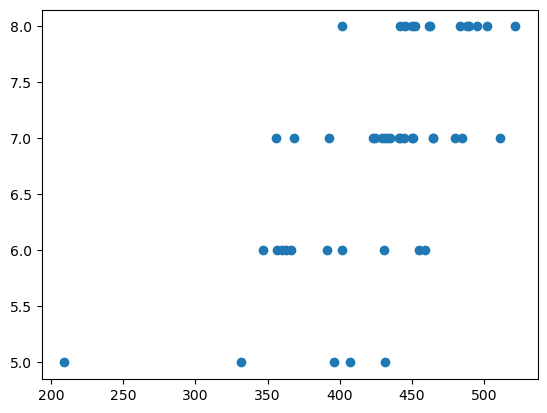

In [115]:
import matplotlib.pyplot as plt

plt.scatter(csv_dataframes['scheme24'].sleep_minutesAsleep, csv_dataframes['scheme24'].sleep_hours_enum)
plt.show()

# Regress enum sleep hours question on fitbit sleep_minutesAsleep

In [108]:
import matplotlib.pyplot as plt 
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import os

def linear_regression_results(dependent_features, independent_features,
                              formula_string, df, test_df, metabolite_anns=False):
    
    """Get a single association for a specific combination of features."""
    
    # Initialize an empty list to store the results
    all_results = []

    # Iterate through all combinations of dependent and independent features
    for dependent_feature in dependent_features:
        for independent_feature in independent_features:

            # Define the formula using the provided dependent and independent variables
            formula = formula_string.format(dependent_feature = dependent_feature,
                                            independent_feature = independent_feature)
            df_dropped_nan = df.dropna(subset=[dependent_feature, independent_feature])
            fitted = ols(formula, data=df_dropped_nan).fit()

            # Compute R2 for the fitted model on the holdout test df
            # Get the residuals and calculate their sum of squares
            test_df_dropped_nan = test_df.dropna(subset=[dependent_feature, independent_feature])
            
            y_test = test_df_dropped_nan[dependent_feature]
            predictions = fitted.predict(test_df_dropped_nan)
            residuals = y_test - predictions
            RSS = np.sum(residuals**2)

            # Calculate the total sum of squares
            y_mean = np.mean(y_test)
            TSS = np.sum((y_test - y_mean)**2)
            
            # Calculate R-squared
            r2_test = 1 - (RSS / TSS)

            # Create a Series with the results
            result_series = pd.Series({
                "dependent_feature": dependent_feature,
                "independent_feature": independent_feature,
                "beta": fitted.params[independent_feature],
                "t_statistic": fitted.tvalues[independent_feature],
                "p": fitted.pvalues[independent_feature],
                "n_train": fitted.nobs,
                "n_test": len(y_test),
                "r2_train": fitted.rsquared,
                "r2_test": r2_test,
                "formula": formula
                })

            all_results.append(result_series)

            """
            #Code to make residual plots
            # modify figure size 
            fig = plt.figure(figsize=(14, 8))
            # creating regression plots 
            fig = sm.graphics.plot_regress_exog(fitted, independent_feature, fig=fig)
            fig.show()
            """


    # Turn the all_results list into a pandas df
    tests = pd.DataFrame(all_results)

    if metabolite_anns == True:
        # add the metabolite metadata and calculate corrected p-value, q
        anns = get_snapshot("metabolomics_metadata").iloc[:, 0:8]
        anns["independent_feature"] = "metabolite_" + anns.CHEMICAL_ID.astype(str)
        tests = pd.merge(tests, anns, on="independent_feature")
        #tests["q"] = multipletests(tests["p"], method="fdr_bh")[1]
        print("This is metabolite regression")

    else:
        print("This is microbe regression")
    
    return tests

#### Ooops, it doesn't look like there are any dfs where the weird fitbit vendor date is true, so these must all be AFTER that time (2017-03). Also, there are no instances of FitBit vendor, only hapi-fitbit

In [26]:
for i in range(len(csvs)):
    name = 'scheme' + str(i)
    df = csv_dataframes[name]
    fitbit_vendor = df.aggregated_vendor.value_counts()
    fitbit_vendor_date = df.vendor_weird_date.value_counts()
    q_vendor = df.sleep_q_vendor.value_counts()
    print(f'df: {name}\n\nfitbit_vendor: {fitbit_vendor}\n\nfitbit_vendor_date: {fitbit_vendor_date}\n\nq_vendor: {q_vendor}\n\n')

df: scheme0

fitbit_vendor: aggregated_vendor
hapi-fitbit       235
hapi-garmin         6
hapi-healthkit      4
Name: count, dtype: int64

fitbit_vendor_date: vendor_weird_date
False    245
Name: count, dtype: int64

q_vendor: sleep_q_vendor
Assessments    2280
Name: count, dtype: int64


df: scheme1

fitbit_vendor: aggregated_vendor
hapi-fitbit    134
Name: count, dtype: int64

fitbit_vendor_date: vendor_weird_date
False    134
Name: count, dtype: int64

q_vendor: sleep_q_vendor
Assessments    2280
Name: count, dtype: int64


df: scheme2

fitbit_vendor: aggregated_vendor
hapi-fitbit       231
hapi-garmin         7
hapi-healthkit      2
Name: count, dtype: int64

fitbit_vendor_date: vendor_weird_date
False    240
Name: count, dtype: int64

q_vendor: sleep_q_vendor
Assessments    2280
Name: count, dtype: int64


df: scheme3

fitbit_vendor: aggregated_vendor
hapi-fitbit       228
hapi-garmin         6
hapi-healthkit      4
Name: count, dtype: int64

fitbit_vendor_date: vendor_weird_date


In [116]:
from sklearn.model_selection import train_test_split

fitbit_q_regression_results = {}

for fitbit_q_key in csv_dataframes.keys():
    # Retrieve the DataFrame
    fitbit_q_df = csv_dataframes[fitbit_q_key]

    # Check the number of unique vendors and set formula accordingly
    if fitbit_q_df.aggregated_vendor.nunique() < 2:
        formula = "{dependent_feature} ~ {independent_feature}"
        print(f"{fitbit_q_key}: Using formula without vendor (only one unique vendor).")

    else:
        formula = "{dependent_feature} ~ {independent_feature} + C(aggregated_vendor)"
        print(f"{fitbit_q_key}: Using formula with aggregated vendor.")

    if fitbit_q_df.dropna(subset=["sleep_hours_enum", "sleep_minutesAsleep"]).shape[0] == 0:
        print(f"{fitbit_q_key}: NO DATA after dropping NaNs. Skipping.")
        fitbit_q_regression_results[fitbit_q_key] = "NO DATA"
        continue  # Jumps to the next key in csv_dataframes.keys()

    else:
        pass

    # Run the regression function
    fitbit_vs_questions = linear_regression_results(
        dependent_features=["sleep_hours_enum"],
        independent_features=["sleep_minutesAsleep"],
        formula_string=formula,
        df=fitbit_q_df,
        test_df=fitbit_q_df
    )

    # Store the results
    fitbit_q_regression_results[fitbit_q_key] = fitbit_vs_questions

scheme0: Using formula with aggregated vendor.
This is microbe regression
scheme1: Using formula with aggregated vendor.
This is microbe regression
scheme2: Using formula with aggregated vendor.
This is microbe regression
scheme3: Using formula with aggregated vendor.
This is microbe regression
scheme4: Using formula with aggregated vendor.
This is microbe regression
scheme5: Using formula with aggregated vendor.
This is microbe regression
scheme6: Using formula with aggregated vendor.
This is microbe regression
scheme7: Using formula with aggregated vendor.
This is microbe regression
scheme8: Using formula with aggregated vendor.
This is microbe regression
scheme9: Using formula with aggregated vendor.
This is microbe regression
scheme10: Using formula with aggregated vendor.
This is microbe regression
scheme11: Using formula with aggregated vendor.
This is microbe regression
scheme12: Using formula with aggregated vendor.
This is microbe regression
scheme13: Using formula with aggreg

In [117]:
import pandas as pd
import numpy as np

# List to store extracted regression results
all_fitbit_q_regressions = []

# Iterate through each key in the regression results dictionary
for fitbit_q_key, fitbit_q_df in fitbit_q_regression_results.items():
    if isinstance(fitbit_q_df, pd.DataFrame) and not fitbit_q_df.empty:
        # Access the first row safely
        row = fitbit_q_df.iloc[0]

        # Append extracted values
        all_fitbit_q_regressions.append([
            fitbit_q_key,
            row.get("beta", np.nan),
            row.get("p", np.nan),
            row.get("n_train", np.nan),
            row.get("n_test", np.nan),
            row.get("r2_train", np.nan),
            row.get("r2_test", np.nan),
            row.get("formula", "N/A")
        ])
    else:
        # Handle "NO DATA" or empty DataFrames
        all_fitbit_q_regressions.append([
            fitbit_q_key,
            np.nan,  # beta
            np.nan,  # p
            np.nan,  # n_train
            np.nan,  # n_test
            np.nan,  # r2_train
            np.nan,  # r2_test
            "NO DATA"  # formula
        ])

# Convert to DataFrame
fitbit_q_all_summary_df = pd.DataFrame(
    all_fitbit_q_regressions,
    columns=["fitbit_q_df", "beta", "p", "n_train", "n_test", "r2_train", "r2_test", "formula"]
)

In [111]:
fitbit_q_all_summary_df

,fitbit_q_df,beta,p,n_train,n_test,r2_train,r2_test,formula
0,scheme0,0.001732,2.594211e-02,108.0,108.0,0.045924,0.045924,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
1,scheme1,0.002278,8.369969e-02,53.0,53.0,0.057513,0.057513,sleep_hours_enum ~ sleep_minutesAsleep
2,scheme2,0.001720,2.326225e-02,102.0,102.0,0.050429,0.050429,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
3,scheme3,0.001730,2.614773e-02,101.0,101.0,0.048974,0.048974,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
4,scheme4,0.001733,2.619240e-02,108.0,108.0,0.045774,0.045774,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
5,scheme5,0.001725,2.559739e-02,93.0,93.0,0.053570,0.053570,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
6,scheme6,0.008723,1.205519e-05,57.0,57.0,0.296263,0.296263,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
7,scheme7,0.009615,3.498385e-06,56.0,56.0,0.331108,0.331108,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...
8,scheme8,0.009640,3.408304e-06,56.0,56.0,0.331733,0.331733,sleep_hours_enum ~ sleep_minutesAsleep
9,scheme9,0.003006,5.261393e-03,56.0,56.0,0.135440,0.135440,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...


In [118]:
# Create a new column with lists of strings from `csv_processing_notes`
fitbit_q_all_summary_df["processing_notes"] = fitbit_q_all_summary_df["fitbit_q_df"].map(
    lambda scheme: csv_processing_notes.get(scheme, "").split("\n")  # Split by '\n' and default to empty list
)

In [119]:
# clean up the df columns so it's nice and easy to read
fitbit_q_all_summary_df.drop(columns=['n_train', 'r2_test'], inplace=True)
fitbit_q_all_summary_df['p'] = round(fitbit_q_all_summary_df.p, 5)
fitbit_q_all_summary_df.rename(columns={'n_test': 'N', 'r2_train': 'R_squared'})

,fitbit_q_df,beta,p,N,R_squared,formula,processing_notes
0,scheme0,0.001009,0.12099,153,0.020443,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,"[merge_microbe called with days_apart=15, feat..."
1,scheme1,0.001998,0.05570,77,0.058638,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[replace_outliers_iqr called with columns=['sl...
2,scheme2,0.000953,0.14326,146,0.019232,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[replace_outliers_iqr called with columns=['sl...
3,scheme3,0.001021,0.12177,138,0.022747,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[replace_outliers_iqr called with columns=['be...
4,scheme4,0.001020,0.11713,153,0.020776,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[filter_by_time_difference called with hours=3...
5,scheme5,0.000978,0.14362,129,0.021872,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[replace_outliers_iqr called with columns=['sl...
6,scheme6,0.007726,0.00005,72,0.222050,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[first made total_min column which is sum of a...
7,scheme7,0.008391,0.00002,71,0.241807,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[replace_outliers_iqr called with columns=['sl...
8,scheme8,0.008482,0.00002,72,0.245313,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[only keep rows where vendor == Fitbit or hapi...
9,scheme9,0.002817,0.00645,68,0.120666,sleep_hours_enum ~ sleep_minutesAsleep + C(agg...,[only keep rows where vendor == Fitbit or hapi...


^^^ Use scheme25 (scheme26 is the same just has season and weekend-weekday ratio additionally added) because it uses the empirically/data-driven defined missingness patterns, versus schemes before 14 used the unclear "vendor" column where each vendor category was comprised of multiple different missingness patterns.

In [52]:
# save the sleep_features and labels like that
import json

with open('sleep_features.json', 'w') as f:
    json.dump(sleep_features, f)
with open('activity_features.json', 'w') as f:
    json.dump(activity_features, f)
with open('covariates.json', 'w') as f:
    json.dump(covariates, f)

In [263]:
fitbit_q_all_summary_df.iloc[18][-1]

["replace_outliers_iqr_by_vendor called with columns=['sleep_minutesToFallAsleep'], replace_zeroes=False | replace_outliers_iqr_by_vendor called with columns=['bedtime_int'], replace_zeroes=True | drop_nulls called with subset of columns=['bedtime_int', 'sleep_minutesToFallAsleep'], any_or_all=any | filter_by_time_difference called with hours=3 | drop rows in miss1 and miss5 where total min is less than 1200, then drop total min column | merge_microbe called with days_apart=15, features=sleep_and_activity_features, min_count=5 | merge_covariates called with days_apart=30.0 | merged sleep_hours questionnaire to nearest microbe days in program within 30 days"]